In [ ]:
import json
import os
import random
import shutil

import numpy as np
import pandas as pd
from scipy.signal import argrelextrema

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv1D, SpatialDropout1D, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, confusion_matrix, classification_report

# M1 (Pivot Gate)

### Importing Data

In [1]:
start_time = "2026-04-05 00:00:00"
end_time   = "2026-10-01 00:00:00"

FILEPATH = 'libs/BTCUSDT-M5.csv'

df = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index, unit='s', errors='coerce')

df = df[(df.index >= start_time) & (df.index <= end_time)]

df.info()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 255626 entries, 2024-02-01 00:00:00 to 2026-07-08 01:55:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Volume  255626 non-null  int64  
 1   Open    255626 non-null  float64
 2   High    255626 non-null  float64
 3   Low     255626 non-null  float64
 4   Close   255626 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 11.7 MB


## M1 - Extended Kalman Filter

Note: Before any features are built, the raw 5-minute candles pass through an adaptive Kalman filter that I've kept proprietary, so its code isn't included in this repo. Its purpose is denoising: it strips microstructure noise from the OHLC series and returns a cleaner price path along with a few derived signals (a smoothed velocity, a running volatility estimate, and the filter's innovations) that feed the models. The figure below illustrates the effect (raw vs. filtered price) so the behaviour is visible without the internals. Everything downstream runs on the filter's precomputed outputs, so the results in this notebook remain fully reproducible.

In [16]:
def plot_filter_effect(df, n=100, start=None, save=None):
    if start is None:
        start = np.random.randint(0, len(df) - n)
    win = df.iloc[start:start + n].reset_index(drop=True)

    def candles(ax, o, h, l, c, title):
        x = np.arange(len(win))
        up = (win[c] >= win[o]).to_numpy()
        hi = win[[o, h, l, c]].max(axis=1).to_numpy()
        lo = win[[o, h, l, c]].min(axis=1).to_numpy()
        green, red = '#2ca555', '#d32f2f'
        ax.vlines(x[up],  lo[up],  hi[up],  color=green, lw=0.7)
        ax.vlines(x[~up], lo[~up], hi[~up], color=red,   lw=0.7)
        ax.bar(x[up],  (win[c] - win[o]).to_numpy()[up],  bottom=win[o].to_numpy()[up],  width=0.6, color=green)
        ax.bar(x[~up], (win[o] - win[c]).to_numpy()[~up], bottom=win[c].to_numpy()[~up], width=0.6, color=red)
        ax.set_title(title)
        ax.grid(alpha=0.2)

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    for col, color in [('Open', 'tab:cyan'), ('High', 'tab:blue'),
                       ('Low', 'orange'), ('Close', 'black')]:
        axs[0, 0].plot(win[f'{col}_EKF'], color=color, lw=1.2, label=col)
        axs[0, 1].plot(win[col],               color=color, lw=1.2, alpha=0.6, label=col)
    axs[0, 0].set_title('Smoothed price (noise removed)')
    axs[0, 1].set_title('Raw price')
    axs[0, 0].legend(); axs[0, 0].grid(alpha=0.2)
    axs[0, 1].legend(); axs[0, 1].grid(alpha=0.2)

    candles(axs[1, 0], 'Open_EKF', 'High_EKF', 'Low_EKF', 'Close_EKF', 'Smoothed candles')
    candles(axs[1, 1], 'Open', 'High', 'Low', 'Close', 'Raw candles')

    fig.suptitle(f'Filter effect — {n}-bar slice (from index {start})', fontsize=15)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    return start

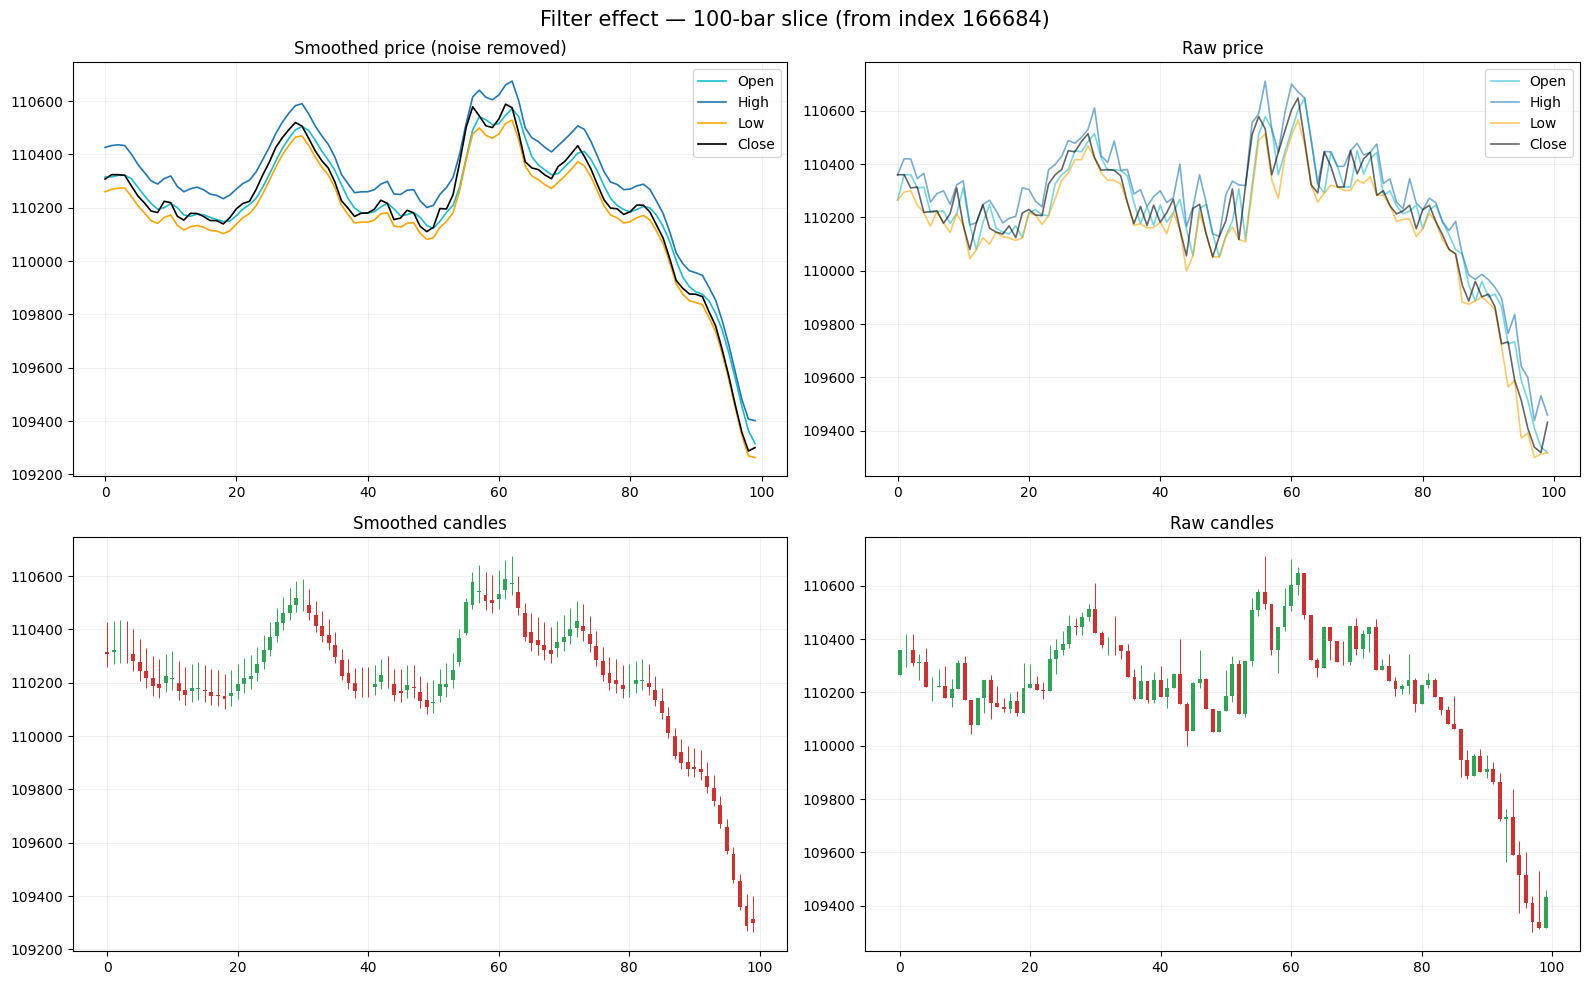

166684

In [19]:
plot_filter_effect(df)

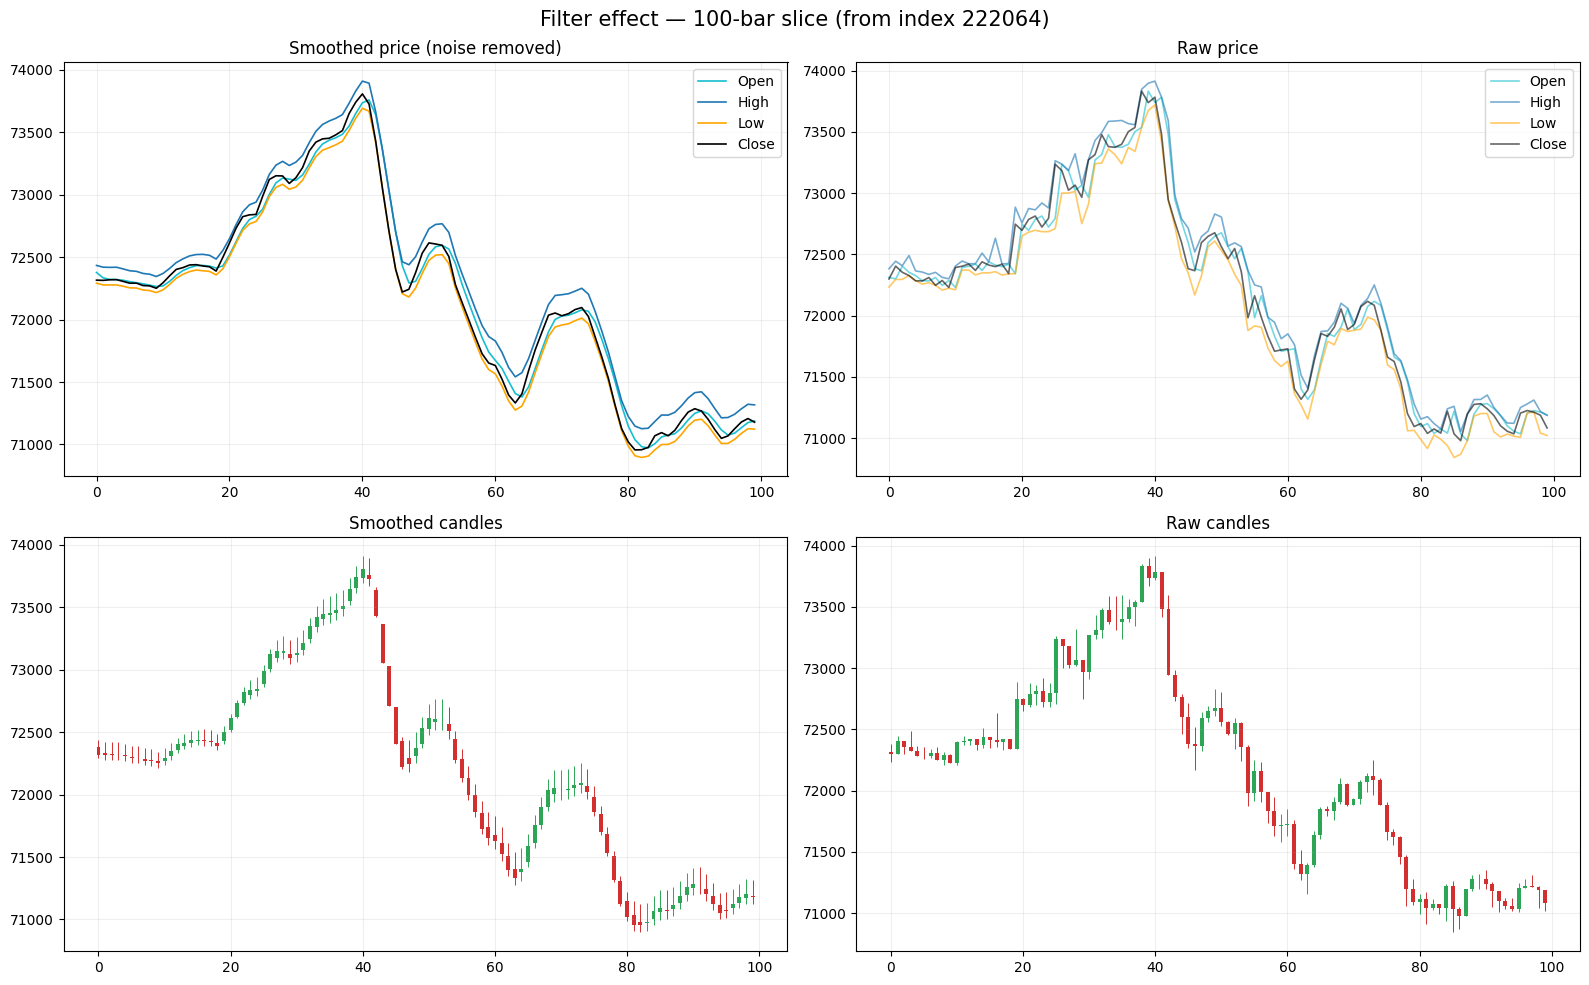

222064

In [17]:
plot_filter_effect(df)

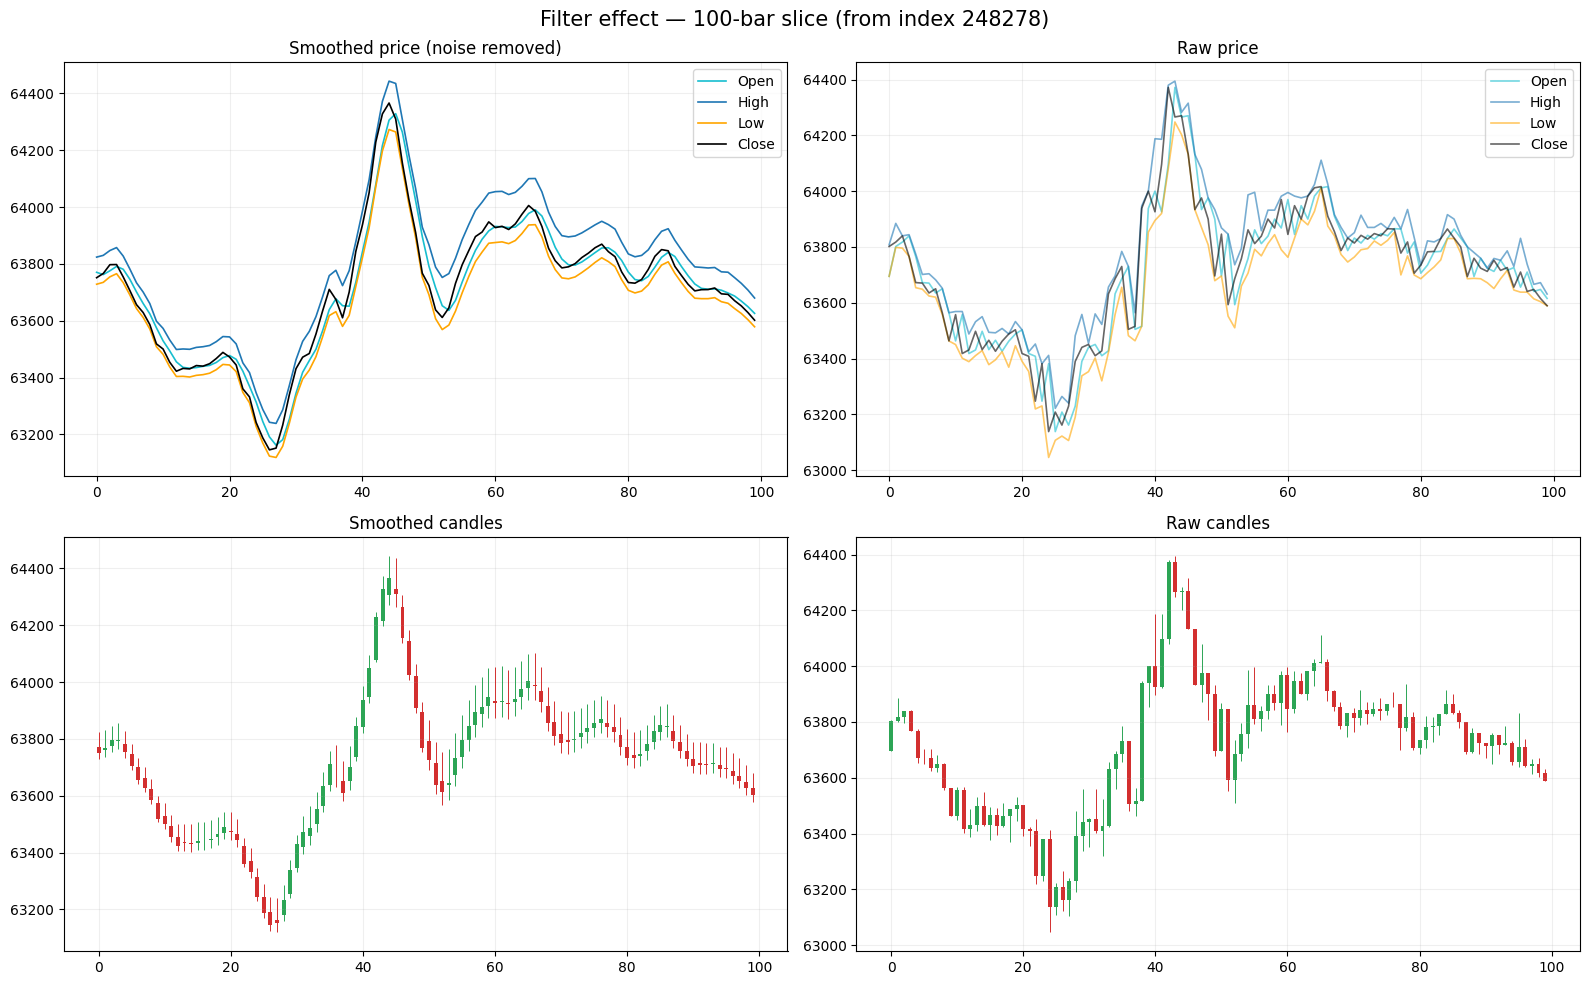

248278

In [22]:
plot_filter_effect(df)

In [ ]:
# M1 only sees the smoothed candles
df.drop(columns=['Open', 'High', 'Low', 'Close'], inplace=True)

df.rename(columns={'Open_EKF': 'Open',
                   'High_EKF': 'High',
                   'Low_EKF': 'Low',
                   'Close_EKF': 'Close'}, inplace=True)

df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'vol_estimate', 'q_multiplier',
         'norm_innovation', 'filtered_velocity', 'target_price', 'target_velocity']]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 255626 entries, 2024-02-01 00:00:00 to 2026-07-08 01:55:00
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Open               255626 non-null  float64
 1   High               255626 non-null  float64
 2   Low                255626 non-null  float64
 3   Close              255626 non-null  float64
 4   Volume             255626 non-null  int64  
 5   vol_estimate       255626 non-null  float64
 6   q_multiplier       255626 non-null  float64
 7   norm_innovation    255626 non-null  float64
 8   filtered_velocity  255626 non-null  float64
 9   target_price       255626 non-null  float64
 10  target_velocity    255626 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 23.4 MB


## M1 - Class Y

In [ ]:
order = 90

peaks_idx = argrelextrema(df['High'].values, np.greater, order=order)[0]
troughs_idx = argrelextrema(df['Low'].values, np.less, order=order)[0]

df['target'] = 0
df.loc[df.index[peaks_idx], 'target'] = 1
df.loc[df.index[troughs_idx], 'target'] = 1

print(f"Total Data Points: {len(df)}")
print(f"Total Pivots: {df['target'].sum()}")
print(f"Percentage of Target candles: {df['target'].mean() * 100:.2f}%")

Total Data Points: 255626
Total Pivots: 1899
Percentage of Target candles: 0.74%


### target smearing

In [ ]:
# widen every pivot by one candle so the model isn't punished for firing one bar off
df['target'] = 0
df.loc[df.index[peaks_idx], 'target'] = 1
df.loc[df.index[troughs_idx], 'target'] = 1
df['target'] = df['target'].rolling(window=2, center=True, min_periods=1).max()
df['target'] = df['target'].fillna(0).astype(int)

print(f"Total Data Points: {len(df)}")
print(f"Total Pivots: {df['target'].sum()}")
print(f"Percentage of Target candles: {df['target'].mean() * 100:.2f}%")

Total Data Points: 255626
Total Pivots: 3798
Percentage of Target candles: 1.49%


### Visualisation of the logic

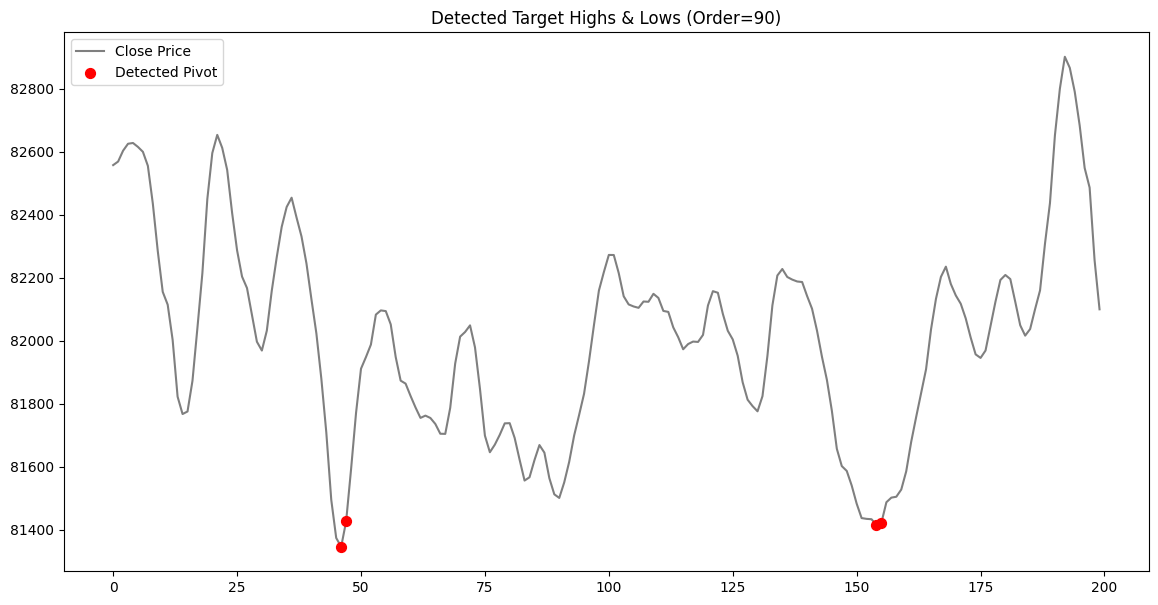

In [ ]:
slice_len = 200
start_idx = np.random.randint(0, len(df) - slice_len)
subset = df.iloc[start_idx:start_idx + slice_len].reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(subset.index, subset['Close'], color='black', alpha=0.5, label='Close Price')
pivots = subset[subset['target'] == 1]
plt.scatter(pivots.index, pivots['Close'], color='red', s=50, label='Detected Pivot', zorder=5)
plt.title(f'Detected Target Highs & Lows (Order={order})')
plt.legend()
plt.show()

In [ ]:
df.rename(columns={'target': 'target_pivot'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 255626 entries, 2024-02-01 00:00:00 to 2026-07-08 01:55:00
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Open               255626 non-null  float64
 1   High               255626 non-null  float64
 2   Low                255626 non-null  float64
 3   Close              255626 non-null  float64
 4   Volume             255626 non-null  int64  
 5   vol_estimate       255626 non-null  float64
 6   q_multiplier       255626 non-null  float64
 7   norm_innovation    255626 non-null  float64
 8   filtered_velocity  255626 non-null  float64
 9   target_price       255626 non-null  float64
 10  target_velocity    255626 non-null  float64
 11  target_pivot       255626 non-null  int64  
dtypes: float64(10), int64(2)
memory usage: 33.4 MB


## M1 - Feauture Engineering

In [ ]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / loss)

def true_range(df):
    prev_close = df['Close'].shift(1)
    return pd.concat([df['High'] - df['Low'],
                      (df['High'] - prev_close).abs(),
                      (df['Low'] - prev_close).abs()], axis=1).max(axis=1)

# price
bb_mid = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
df['feat_bb_width'] = (bb_upper - bb_lower) / bb_mid

atr = true_range(df).rolling(14).mean()
df['feat_atr_norm'] = atr / df['Close']

dc_high = df['High'].rolling(20).max()
dc_low = df['Low'].rolling(20).min()
df['feat_dc_width'] = (dc_high - dc_low) / df['Close']

df['feat_rsi'] = calculate_rsi(df['Close'], period=14)
df['feat_rsi_roc'] = df['feat_rsi'].diff(3)

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
macd = ema_12 - ema_26
signal_line = macd.ewm(span=9, adjust=False).mean()
df['feat_macd_hist'] = macd - signal_line

df['feat_roc_3'] = df['Close'].pct_change(3)
df['feat_roc_12'] = df['Close'].pct_change(12)

log_ret = np.log(df['Close'] / df['Close'].shift(1))
df['feat_hist_vol'] = log_ret.rolling(96).std()

ema_7 = df['Close'].ewm(span=7, adjust=False).mean()
ema_25 = df['Close'].ewm(span=25, adjust=False).mean()
df['feat_ema_spread'] = (ema_7 - ema_25) / df['Close']

body_size = (df['Close'] - df['Open']).abs()
total_range = df['High'] - df['Low']
df['feat_body_dominance'] = body_size / total_range.replace(0, 1)

# volume
vol_ma = df['Volume'].rolling(20).mean()
df['feat_rvol'] = df['Volume'] / vol_ma
df['feat_vroc'] = df['Volume'].pct_change(3)
df['feat_vol_std'] = df['Volume'].rolling(20).std() / vol_ma
df['feat_vol_price_corr'] = df['Close'].rolling(12).corr(df['Volume'])

# EKF-derived
vel = df['filtered_velocity'].values
evol = df['vol_estimate'].values
qm = df['q_multiplier'].values
ni = df['norm_innovation'].values
inv_vol = 1.0 / (evol + 1e-10)
log_c = np.log(df['Close'].values)
n = len(df)

# how much each close surprised the filter's one-step prediction
pred = np.empty(n)
pred[0] = log_c[0]
pred[1:] = log_c[:-1] + vel[:-1]
innov = log_c - pred
innov_norm = innov * inv_vol

df['feat_innov_norm'] = innov_norm
df['feat_innov_ema'] = pd.Series(innov_norm).ewm(span=20).mean().values

# rolling autocorrelation of the innovations
s_innov = pd.Series(innov)
s_lag = s_innov.shift(1)
denom = (s_innov.rolling(20).std() * s_lag.rolling(20).std()).values
denom[denom < 1e-20] = 1e-20
autocorr = s_innov.rolling(20).cov(s_lag).values / denom
autocorr[np.isnan(autocorr)] = 0.0
df['feat_innov_autocorr'] = autocorr

df['feat_innov_mag'] = pd.Series(ni).ewm(span=20).mean().values
df['feat_velocity_norm'] = vel * inv_vol
df['feat_accel_norm'] = np.diff(vel, prepend=vel[0]) * inv_vol

# volatility regime: fast vs slow Parkinson vol (same spans as the EKF)
pk = 1.0 / (2.0 * np.sqrt(np.log(2.0)))
raw_pv = (np.log(df['High'].values) - np.log(df['Low'].values)) * pk
vol_fast = pd.Series(raw_pv).ewm(span=ekf.vol_fast_span).mean().values
vol_slow = pd.Series(raw_pv).ewm(span=ekf.vol_slow_span).mean().values
df['feat_vol_ratio'] = vol_fast / (vol_slow + 1e-10)
df['feat_vol_change'] = np.diff(evol, prepend=evol[0]) * inv_vol

df['feat_q_mult'] = qm
df['feat_q_mult_roc'] = np.diff(qm, prepend=qm[0])

rng = df['High'].values - df['Low'].values
rng_safe = np.where(rng < 1e-10, 1.0, rng)
df['feat_body_ratio'] = np.abs(df['Close'].values - df['Open'].values) / rng_safe

# share of the last 10 innovations pushing the same way
signs = np.sign(innov)
cs_signs = np.insert(np.cumsum(signs), 0, 0.0)
dir_con = np.zeros(n)
dir_con[10:] = (cs_signs[10:n] - cs_signs[:n-10]) / 10.0
df['feat_dir_consistency'] = dir_con

df['feat_ekf_log_ret'] = np.diff(log_c, prepend=log_c[0])

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

feature_list = [c for c in df.columns if c.startswith('feat_')]
print(f"Total Features: {len(feature_list)}")
print(feature_list)

Total Features: 28
['feat_bb_width', 'feat_atr_norm', 'feat_dc_width', 'feat_rsi', 'feat_rsi_roc', 'feat_macd_hist', 'feat_roc_3', 'feat_roc_12', 'feat_hist_vol', 'feat_ema_spread', 'feat_body_dominance', 'feat_rvol', 'feat_vroc', 'feat_vol_std', 'feat_vol_price_corr', 'feat_innov_norm', 'feat_innov_ema', 'feat_innov_autocorr', 'feat_innov_mag', 'feat_velocity_norm', 'feat_accel_norm', 'feat_vol_ratio', 'feat_vol_change', 'feat_q_mult', 'feat_q_mult_roc', 'feat_body_ratio', 'feat_dir_consistency', 'feat_ekf_log_ret']


## M1 - Scaling & Sequencies

In [ ]:
start_time = "2024-02-01 00:00:00"
end_time   = "2026-07-09 00:00:00"

df = df[(df.index >= start_time) & (df.index <= end_time)]

In [ ]:
SEQ_LEN       = 60
LABEL_HORIZON = 135
EMBARGO       = 75
CHUNK_DAYS    = 30
TEST_DAYS     = 90

# how each chunk is divided between the two models
PCT_IN_CHUNK = {
    'm1_train': 20 / 100,
    'm1_val':   10 / 100,
    'm2_train': 50 / 100,
    'm2_val':   20 / 100,
}

feature_cols = [c for c in df.columns if 'feat_' in c]
target_col = 'target_pivot'

ROLLING_SPAN = 500
Z_CLIP = 8.0

# bounded features get a fixed affine map to ~[-0.5, 0.5]; the rest a causal EWM z-score
AFFINE_FEATURES = {
    'feat_rsi':             (0.01, -0.5),
    'feat_body_dominance':  (1.0, -0.5),
    'feat_body_ratio':      (1.0, -0.5),
    'feat_vol_price_corr':  (1.0,  0.0),
    'feat_innov_autocorr':  (1.0,  0.0),
    'feat_dir_consistency': (1.0,  0.0),
}

for col in feature_cols:
    if col in AFFINE_FEATURES:
        scale, offset = AFFINE_FEATURES[col]
        df[col] = df[col] * scale + offset
    else:
        ewm_mean = df[col].ewm(span=ROLLING_SPAN, min_periods=60).mean()
        ewm_std = df[col].ewm(span=ROLLING_SPAN, min_periods=60).std().clip(lower=1e-12)
        df[col] = ((df[col] - ewm_mean) / ewm_std).clip(-Z_CLIP, Z_CLIP)

df.dropna(inplace=True)

idx_all = df.index
X_all = df[feature_cols].values
y_all = df[target_col].values
N = len(df)

# the last TEST_DAYS are held out entirely, the rest is cut into chunks
test_start = idx_all.max() - pd.Timedelta(days=TEST_DAYS)
test_positions = np.where(idx_all >= test_start)[0]
rolling_idx = idx_all[idx_all < test_start]
rolling_start, rolling_end = rolling_idx.min(), rolling_idx.max()

chunk_bounds = []
cur = rolling_start
while cur < rolling_end:
    nxt = min(cur + pd.Timedelta(days=CHUNK_DAYS), rolling_end + pd.Timedelta(minutes=1))
    chunk_bounds.append((cur, nxt))
    cur = nxt

print(f"Total rows after normalization: {N}")
print(f"Rolling region: {rolling_start}  -->  {rolling_end}")
print(f"Final TEST:     {idx_all[test_positions[0]]}  -->  {idx_all[test_positions[-1]]}  ({len(test_positions)} rows)")
print(f"CHUNK_DAYS = {CHUNK_DAYS}  -->  {len(chunk_bounds)} chunks")

def segment_chunk(chunk_start, chunk_end, first_chunk, last_chunk):
    pos = np.where((idx_all >= chunk_start) & (idx_all < chunk_end))[0]
    if len(pos) == 0:
        return None
    cs, ce = pos[0], pos[-1] + 1
    L = ce - cs
    b1 = cs + int(L * PCT_IN_CHUNK['m1_train'])
    b2 = cs + int(L * (PCT_IN_CHUNK['m1_train'] + PCT_IN_CHUNK['m1_val']))
    b3 = cs + int(L * (PCT_IN_CHUNK['m1_train'] + PCT_IN_CHUNK['m1_val'] + PCT_IN_CHUNK['m2_train']))
    raw = {
        'm1_train': (cs, b1),
        'm1_val':   (b1, b2),
        'm2_train': (b2, b3),
        'm2_val':   (b3, ce),
    }
    keys = ['m1_train', 'm1_val', 'm2_train', 'm2_val']
    segs = {}
    for i, k in enumerate(keys):
        s, e = raw[k]
        if i < len(keys) - 1:
            e = max(s, e - LABEL_HORIZON)
        if i > 0:
            s = min(e, s + EMBARGO)
        segs[k] = (s, e)
    if not last_chunk:
        s, e = segs['m2_val']
        segs['m2_val'] = (s, max(s, e - LABEL_HORIZON))
    if not first_chunk:
        s, e = segs['m1_train']
        segs['m1_train'] = (min(e, s + EMBARGO), e)
    return segs

seg_positions = {k: [] for k in ['m1_train', 'm1_val', 'm2_train', 'm2_val']}
for ci, (cs_ts, ce_ts) in enumerate(chunk_bounds):
    segs = segment_chunk(cs_ts, ce_ts, ci == 0, ci == len(chunk_bounds) - 1)
    if segs is None:
        continue
    for k, (s, e) in segs.items():
        if e > s:
            seg_positions[k].append((s, e))

def build_sequences(slices):
    Xs, ys, ts = [], [], []
    for s, e in slices:
        for i in range(max(s + SEQ_LEN, SEQ_LEN), e):
            Xs.append(X_all[i - SEQ_LEN:i])
            ys.append(y_all[i])
            ts.append(idx_all[i])
    if not Xs:
        return (np.empty((0, SEQ_LEN, len(feature_cols))),
                np.empty(0, dtype=y_all.dtype), pd.DatetimeIndex([]))
    return np.array(Xs), np.array(ys), pd.DatetimeIndex(ts)

test_slice = [(test_positions[0], test_positions[-1] + 1)] if len(test_positions) else []

X_train, y_train, ts_train = build_sequences(seg_positions['m1_train'])
X_val,   y_val,   ts_val   = build_sequences(seg_positions['m1_val'])
X_test,  y_test,  ts_test  = build_sequences(test_slice)

print(f"Tensors:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")

if len(y_train) > 0:
    print(f"\nM1-TRAIN positive class: {100.0 * (y_train == 1).sum() / len(y_train):.2f}%")

# save the exact split boundaries so the M2 stage and the tester reuse them
os.makedirs('libs', exist_ok=True)

def slices_to_ts(slices):
    return [{'start': idx_all[s].isoformat(), 'end': idx_all[e - 1].isoformat()}
            for s, e in slices]

splits_payload = {
    'created_utc':   pd.Timestamp.utcnow().isoformat(),
    'seq_len':       SEQ_LEN,
    'label_horizon': LABEL_HORIZON,
    'embargo':       EMBARGO,
    'rolling_span':  ROLLING_SPAN,
    'chunk_days':    CHUNK_DAYS,
    'test_days':     TEST_DAYS,
    'pct_in_chunk':  PCT_IN_CHUNK,
    'feature_cols':  feature_cols,
    'slices_ts': {
        'm1_train': slices_to_ts(seg_positions['m1_train']),
        'm1_val':   slices_to_ts(seg_positions['m1_val']),
        'm2_train': slices_to_ts(seg_positions['m2_train']),
        'm2_val':   slices_to_ts(seg_positions['m2_val']),
        'test':     slices_to_ts(test_slice),
    },
}
with open('libs/splits.json', 'w') as f:
    json.dump(splits_payload, f, indent=2, default=str)

Total rows after normalization: 255471
Rolling region: 2024-02-01 12:55:00  -->  2026-04-09 01:50:00
Final TEST:     2026-04-09 01:55:00  -->  2026-07-08 01:55:00  (25921 rows)
CHUNK_DAYS = 30  -->  27 chunks
Tensors:
  X_train: (38693, 60, 28)   y_train: (38693,)
  X_val:   (15665, 60, 28)   y_val:   (15665,)
  X_test:  (25861, 60, 28)   y_test:  (25861,)

M1-TRAIN positive class: 1.49%


## M1 - Conv1D + LSTM

### Model Architecture

In [ ]:
tf.keras.utils.set_random_seed(42)

weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))

# dilated causal convs to pick up local patterns, LSTM to aggregate them
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(48, kernel_size=5, padding='causal', dilation_rate=1, activation='relu'),
    Conv1D(48, kernel_size=5, padding='causal', dilation_rate=2, activation='relu'),
    Conv1D(48, kernel_size=5, padding='causal', dilation_rate=4, activation='relu'),
    SpatialDropout1D(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
]
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=metrics)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 48)         │         6,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 48)         │        11,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 60, 48)         │        11,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 48)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,817 (159.44 KB)

 Trainable params: 40,817 (159.44 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

Epoch 1/200
605/605 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.6725 - auc: 0.7333 - loss: 0.6068 - pr_auc: 0.0631 - precision: 0.0443 - recall: 0.6636 - val_accuracy: 0.7665 - val_auc: 0.7978 - val_loss: 0.4583 - val_pr_auc: 0.0987 - val_precision: 0.0603 - val_recall: 0.6826
Epoch 2/200
605/605 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7627 - auc: 0.8652 - loss: 0.4491 - pr_auc: 0.1056 - precision: 0.0752 - recall: 0.8509 - val_accuracy: 0.7483 - val_auc: 0.8380 - val_loss: 0.4366 - val_pr_auc: 0.0991 - val_precision: 0.0636 - val_recall: 0.7874
Epoch 3/200
605/605 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7741 - auc: 0.8880 - loss: 0.3935 - pr_auc: 0.1121 - precision: 0.0826 - recall: 0.9006 - val_accuracy: 0.7216 - val_auc: 0.8438 - val_loss: 0.4798 - val_pr_auc: 0.1148 - val_precision: 0.0603 - val_recall: 0.8263
Epoch 4/200
605/605 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7861 - auc: 0.8997 - loss: 0.3639 - pr_auc: 0.1232 - precision: 0.0888 - recall: 0.92

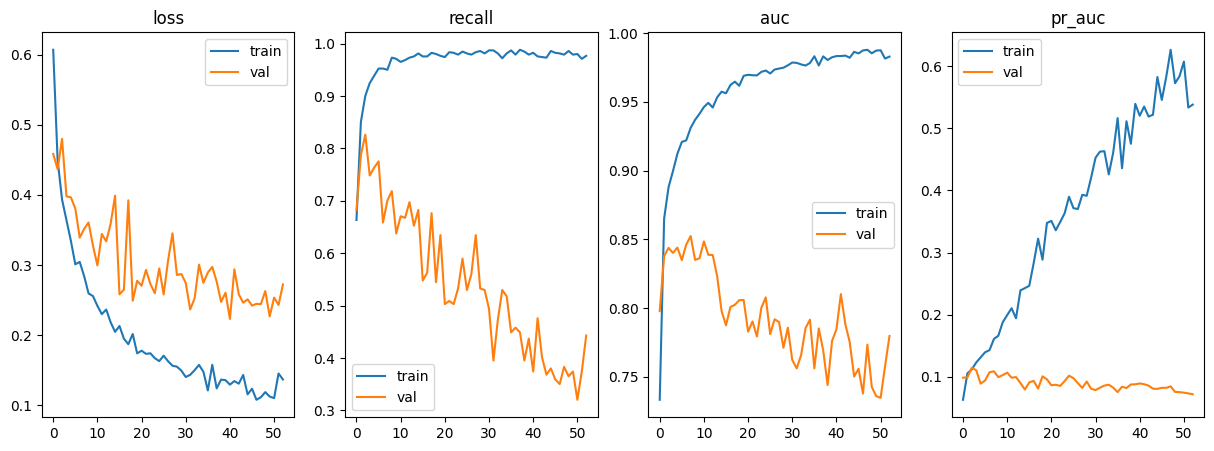

In [ ]:
early_stop = EarlyStopping(monitor='val_pr_auc', patience=50, mode='max', restore_best_weights=True)
checkpoint = ModelCheckpoint('best_pivot_model.keras', monitor='val_pr_auc', mode='max', save_best_only=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=64,
                    validation_data=(X_val, y_val), class_weight=class_weights_dict,
                    callbacks=[early_stop, checkpoint], verbose=1)

plt.figure(figsize=(15, 5))
for i, m in enumerate(['loss', 'recall', 'auc', 'pr_auc'], 1):
    plt.subplot(1, 4, i)
    plt.plot(history.history[m], label='train')
    plt.plot(history.history['val_' + m], label='val')
    plt.title(m)
    plt.legend()
plt.show()

## M1 - Evaluation

490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


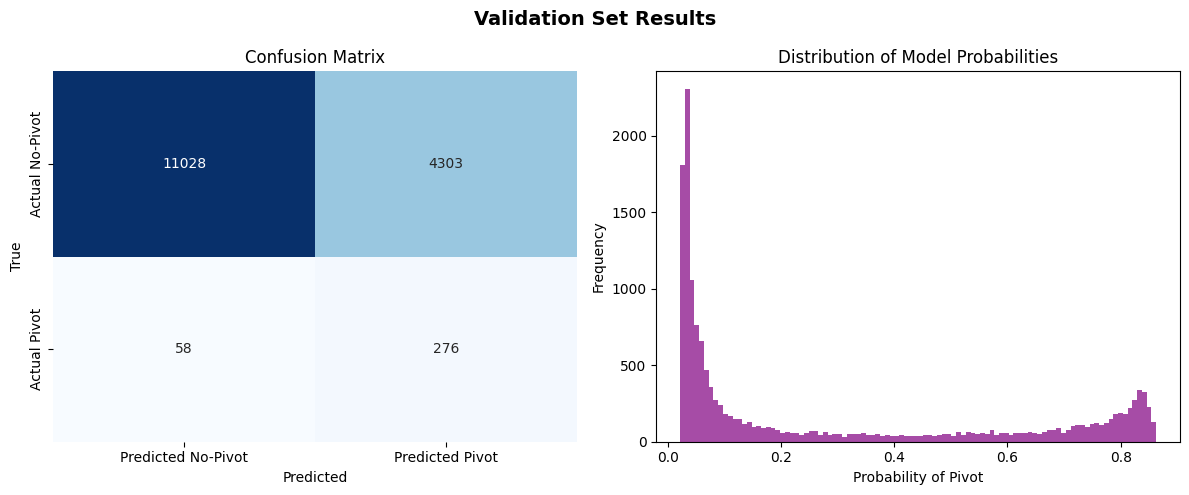

Validation Classification Report
              precision    recall  f1-score   support

    No-Pivot       0.99      0.72      0.83     15331
       Pivot       0.06      0.83      0.11       334

    accuracy                           0.72     15665
   macro avg       0.53      0.77      0.47     15665
weighted avg       0.97      0.72      0.82     15665

809/809 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


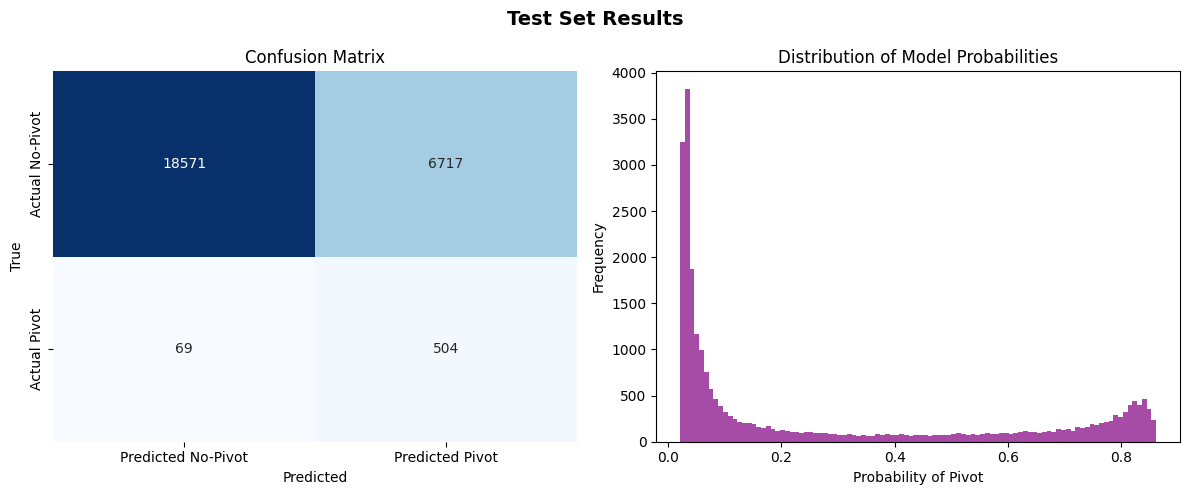

Test Classification Report
              precision    recall  f1-score   support

    No-Pivot       1.00      0.73      0.85     25288
       Pivot       0.07      0.88      0.13       573

    accuracy                           0.74     25861
   macro avg       0.53      0.81      0.49     25861
weighted avg       0.98      0.74      0.83     25861



In [ ]:
for name, X_data, y_data in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_prob = model.predict(X_data, verbose=1)
    y_pred = (y_prob > 0.5).astype(int)

    plt.figure(figsize=(12, 5))
    plt.suptitle(f'{name} Set Results', fontsize=14, fontweight='bold')
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_data, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No-Pivot', 'Predicted Pivot'],
                yticklabels=['Actual No-Pivot', 'Actual Pivot'])
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.subplot(1, 2, 2)
    plt.hist(y_prob, bins=100, color='purple', alpha=0.7)
    plt.title('Distribution of Model Probabilities')
    plt.xlabel('Probability of Pivot')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    print(f"{name} Classification Report")
    print(classification_report(y_data, y_pred, target_names=['No-Pivot', 'Pivot']))

## M1->M2 Handoff

In [ ]:
shutil.copy('best_pivot_model.keras', 'M1-T0_8500.keras')
shutil.copy('libs/splits.json', 'splits.json')
print("best_pivot_model.keras  -->  M1-T0_8500.keras")
print("libs/splits.json        -->  splits.json")

best_pivot_model.keras  -->  M1-T0_8500.keras
libs/splits.json        -->  splits.json


# M2 (GRU Directional)

## Importing Data

In [ ]:
start_time = "2026-04-05 00:00:00"
end_time   = "2026-10-01 00:00:00"

FILEPATH = 'libs/BTCUSDT-M5.csv'

df = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index, unit='s', errors='coerce')

df = df[(df.index >= start_time) & (df.index <= end_time)]

df.info()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 255626 entries, 2024-02-01 00:00:00 to 2026-07-08 01:55:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Volume  255626 non-null  int64  
 1   Open    255626 non-null  float64
 2   High    255626 non-null  float64
 3   Low     255626 non-null  float64
 4   Close   255626 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 11.7 MB


## M2 - Extended Kalman Filter

Same as M1 - Extended Kalman Filter

In [ ]:
df.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close',
                   'Open_EKF': 'Open', 'High_EKF': 'High',
                   'Low_EKF': 'Low', 'Close_EKF': 'Close'}, inplace=True)

df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'vol_estimate', 'q_multiplier',
         'norm_innovation', 'filtered_velocity', 'target_price', 'target_velocity',
         'open', 'low', 'close', 'high']]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 255626 entries, 2024-02-01 00:00:00 to 2026-07-08 01:55:00
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Open               255626 non-null  float64
 1   High               255626 non-null  float64
 2   Low                255626 non-null  float64
 3   Close              255626 non-null  float64
 4   Volume             255626 non-null  int64  
 5   vol_estimate       255626 non-null  float64
 6   q_multiplier       255626 non-null  float64
 7   norm_innovation    255626 non-null  float64
 8   filtered_velocity  255626 non-null  float64
 9   target_price       255626 non-null  float64
 10  target_velocity    255626 non-null  float64
 11  open               255626 non-null  float64
 12  low                255626 non-null  float64
 13  close              255626 non-null  float64
 14  high               255626 non-null  float64
dtypes: float64(14), i

## M2 - M1 Predictions

In [ ]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / loss)

def true_range(df):
    prev_close = df['Close'].shift(1)
    return pd.concat([df['High'] - df['Low'],
                      (df['High'] - prev_close).abs(),
                      (df['Low'] - prev_close).abs()], axis=1).max(axis=1)

# price
bb_mid = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
df['feat_bb_width'] = (bb_upper - bb_lower) / bb_mid

atr = true_range(df).rolling(14).mean()
df['feat_atr_norm'] = atr / df['Close']

dc_high = df['High'].rolling(20).max()
dc_low = df['Low'].rolling(20).min()
df['feat_dc_width'] = (dc_high - dc_low) / df['Close']

df['feat_rsi'] = calculate_rsi(df['Close'], period=14)
df['feat_rsi_roc'] = df['feat_rsi'].diff(3)

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
macd = ema_12 - ema_26
signal_line = macd.ewm(span=9, adjust=False).mean()
df['feat_macd_hist'] = macd - signal_line

df['feat_roc_3'] = df['Close'].pct_change(3)
df['feat_roc_12'] = df['Close'].pct_change(12)

log_ret = np.log(df['Close'] / df['Close'].shift(1))
df['feat_hist_vol'] = log_ret.rolling(96).std()

ema_7 = df['Close'].ewm(span=7, adjust=False).mean()
ema_25 = df['Close'].ewm(span=25, adjust=False).mean()
df['feat_ema_spread'] = (ema_7 - ema_25) / df['Close']

body_size = (df['Close'] - df['Open']).abs()
total_range = df['High'] - df['Low']
df['feat_body_dominance'] = body_size / total_range.replace(0, 1)

# volume
vol_ma = df['Volume'].rolling(20).mean()
df['feat_rvol'] = df['Volume'] / vol_ma
df['feat_vroc'] = df['Volume'].pct_change(3)
df['feat_vol_std'] = df['Volume'].rolling(20).std() / vol_ma
df['feat_vol_price_corr'] = df['Close'].rolling(12).corr(df['Volume'])

# EKF-derived
vel = df['filtered_velocity'].values
evol = df['vol_estimate'].values
qm = df['q_multiplier'].values
ni = df['norm_innovation'].values
inv_vol = 1.0 / (evol + 1e-10)
log_c = np.log(df['Close'].values)
n = len(df)

# how much each close surprised the filter's one-step prediction
pred = np.empty(n)
pred[0] = log_c[0]
pred[1:] = log_c[:-1] + vel[:-1]
innov = log_c - pred
innov_norm = innov * inv_vol

df['feat_innov_norm'] = innov_norm
df['feat_innov_ema'] = pd.Series(innov_norm).ewm(span=20).mean().values

# rolling autocorrelation of the innovations
s_innov = pd.Series(innov)
s_lag = s_innov.shift(1)
denom = (s_innov.rolling(20).std() * s_lag.rolling(20).std()).values
denom[denom < 1e-20] = 1e-20
autocorr = s_innov.rolling(20).cov(s_lag).values / denom
autocorr[np.isnan(autocorr)] = 0.0
df['feat_innov_autocorr'] = autocorr

df['feat_innov_mag'] = pd.Series(ni).ewm(span=20).mean().values
df['feat_velocity_norm'] = vel * inv_vol
df['feat_accel_norm'] = np.diff(vel, prepend=vel[0]) * inv_vol

# volatility regime: fast vs slow Parkinson vol (same spans as the EKF)
pk = 1.0 / (2.0 * np.sqrt(np.log(2.0)))
raw_pv = (np.log(df['High'].values) - np.log(df['Low'].values)) * pk
vol_fast = pd.Series(raw_pv).ewm(span=ekf.vol_fast_span).mean().values
vol_slow = pd.Series(raw_pv).ewm(span=ekf.vol_slow_span).mean().values
df['feat_vol_ratio'] = vol_fast / (vol_slow + 1e-10)
df['feat_vol_change'] = np.diff(evol, prepend=evol[0]) * inv_vol

df['feat_q_mult'] = qm
df['feat_q_mult_roc'] = np.diff(qm, prepend=qm[0])

rng = df['High'].values - df['Low'].values
rng_safe = np.where(rng < 1e-10, 1.0, rng)
df['feat_body_ratio'] = np.abs(df['Close'].values - df['Open'].values) / rng_safe

# share of the last 10 innovations pushing the same way
signs = np.sign(innov)
cs_signs = np.insert(np.cumsum(signs), 0, 0.0)
dir_con = np.zeros(n)
dir_con[10:] = (cs_signs[10:n] - cs_signs[:n-10]) / 10.0
df['feat_dir_consistency'] = dir_con

df['feat_ekf_log_ret'] = np.diff(log_c, prepend=log_c[0])

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

feature_cols = [c for c in df.columns if 'feat_' in c]

# same scaling as M1 training
ROLLING_SPAN = 500
Z_CLIP = 8.0

AFFINE_FEATURES = {
    'feat_rsi':             (0.01, -0.5),
    'feat_body_dominance':  (1.0, -0.5),
    'feat_body_ratio':      (1.0, -0.5),
    'feat_vol_price_corr':  (1.0,  0.0),
    'feat_innov_autocorr':  (1.0,  0.0),
    'feat_dir_consistency': (1.0,  0.0),
}

for col in feature_cols:
    if col in AFFINE_FEATURES:
        scale, offset = AFFINE_FEATURES[col]
        df[col] = df[col] * scale + offset
    else:
        ewm_mean = df[col].ewm(span=ROLLING_SPAN, min_periods=60).mean()
        ewm_std = df[col].ewm(span=ROLLING_SPAN, min_periods=60).std().clip(lower=1e-12)
        df[col] = ((df[col] - ewm_mean) / ewm_std).clip(-Z_CLIP, Z_CLIP)

df.dropna(inplace=True)

SEQ_LEN = 60
threshold = 0.86

X_scaled = df[feature_cols].values
X_inference = np.array([X_scaled[i:i + SEQ_LEN] for i in range(len(X_scaled) - SEQ_LEN)])

model = load_model('M1-T0_8500.keras')
y_prob = model.predict(X_inference, batch_size=1024, verbose=1)
y_pred = (y_prob >= threshold).astype(int)

# first SEQ_LEN bars have no full window behind them
padding = np.full((SEQ_LEN, 1), np.nan)
df['predicted_prob'] = np.vstack([padding, y_prob])
df['predicted_signal'] = np.vstack([padding, y_pred])

print(f"Total Rows: {len(df)}")
print(f"Signals Triggered : {np.nansum(df['predicted_signal'].values)}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Total Rows: 255471
Signals Triggered : 27118.0


In [ ]:
def dedup_signals(df, thresh, gap=3):
    d = df.copy()
    d['__row'] = np.arange(len(d))
    sub = d[d['predicted_prob'] >= thresh]
    sub = sub[~sub.index.duplicated(keep='first')]
    keep, last = [], -np.inf
    for r in sub['__row'].values:
        if r - last > gap:
            keep.append(True)
            last = r
        else:
            keep.append(False)
    keep = np.array(keep, dtype=bool)
    return sub[keep].drop(columns='__row').copy(), sub.index[keep], sub.index[~keep]

deduped, kept_ts, dropped_ts = dedup_signals(df, threshold)

print(f"Deduped signals: {len(deduped)} / {len(df)} candles "
      f"({100 * len(deduped) / len(df):.2f}%)\n")

# signals as % of candles, month by month
candles_pm = df.groupby(df.index.to_period('M')).size()
signals_pm = deduped.groupby(deduped.index.to_period('M')).size()
monthly = pd.DataFrame({'candles': candles_pm, 'signals': signals_pm}).fillna(0).astype(int)
monthly['signal_%'] = 100 * monthly['signals'] / monthly['candles']
print(monthly.to_string(float_format='%.2f'))

Deduped signals: 10523 / 255471 candles (4.12%)

          candles  signals  signal_%
DateTime                            
2024-02      8197      304      3.71
2024-03      8916      338      3.79
2024-04      8640      339      3.92
2024-05      8928      360      4.03
2024-06      8640      346      4.00
2024-07      8928      385      4.31
2024-08      8928      364      4.08
2024-09      8640      359      4.16
2024-10      8940      380      4.25
2024-11      8510      345      4.05
2024-12      8928      377      4.22
2025-01      8928      368      4.12
2025-02      8064      360      4.46
2025-03      8916      396      4.44
2025-04      8640      359      4.16
2025-05      8928      368      4.12
2025-06      8640      395      4.57
2025-07      8928      365      4.09
2025-08      8928      375      4.20
2025-09      8640      343      3.97
2025-10      8940      372      4.16
2025-11      8640      366      4.24
2025-12      8928      368      4.12
2026-01      8928      352

### Visualisation of the logic

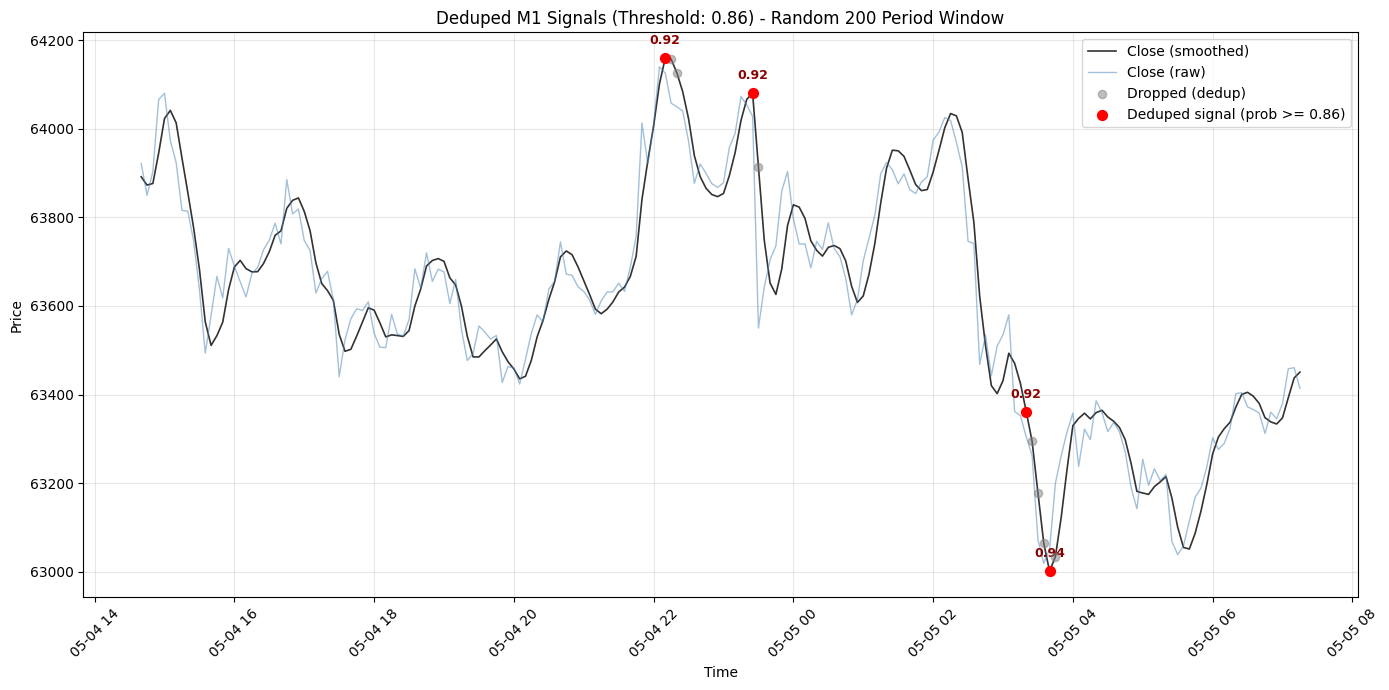

In [ ]:
WINDOW_SIZE = 200

deduped, kept_ts, dropped_ts = dedup_signals(df, threshold)

max_start = len(df) - WINDOW_SIZE
start_idx = random.randint(0, max_start) if max_start > 0 else 0
subset = df.iloc[start_idx:start_idx + WINDOW_SIZE]

plt.figure(figsize=(14, 7))
plt.plot(subset.index, subset['Close'], label='Close (smoothed)',
         color='black', alpha=0.8, linewidth=1.2)
plt.plot(subset.index, subset['close'], label='Close (raw)',
         color='steelblue', alpha=0.5, linewidth=1)

kept_w = subset[subset.index.isin(kept_ts)]
drop_w = subset[subset.index.isin(dropped_ts)]

if len(drop_w):
    plt.scatter(drop_w.index, drop_w['Close'], color='grey', alpha=0.5,
                label='Dropped (dedup)', s=35, zorder=4)
plt.scatter(kept_w.index, kept_w['Close'], color='red',
            label=f'Deduped signal (prob >= {threshold})', s=50, zorder=5)

for time, row in kept_w.iterrows():
    plt.annotate(f"{float(row['predicted_prob']):.2f}", xy=(time, row['Close']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.title(f"Deduped M1 Signals (Threshold: {threshold}) - Random {WINDOW_SIZE} Period Window")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df = df[['Open', 'Close', 'Low', 'High', 'Volume', 'predicted_prob',
         'predicted_signal', 'vol_estimate', 'q_multiplier', 'norm_innovation',
         'filtered_velocity', 'target_price', 'target_velocity',
         'open', 'low', 'close', 'high']]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 255471 entries, 2024-02-01 12:55:00 to 2026-07-08 01:55:00
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Open               255471 non-null  float64
 1   Close              255471 non-null  float64
 2   Low                255471 non-null  float64
 3   High               255471 non-null  float64
 4   Volume             255471 non-null  int64  
 5   predicted_prob     255411 non-null  float64
 6   predicted_signal   255411 non-null  float64
 7   vol_estimate       255471 non-null  float64
 8   q_multiplier       255471 non-null  float64
 9   norm_innovation    255471 non-null  float64
 10  filtered_velocity  255471 non-null  float64
 11  target_price       255471 non-null  float64
 12  target_velocity    255471 non-null  float64
 13  open               255471 non-null  float64
 14  low                255471 non-null  float64
 15  close            

## M2 - Class Y

In [ ]:
def atr(df, h, l, c, period=80):
    hl = df[h] - df[l]
    hc = (df[h] - df[c].shift()).abs()
    lc = (df[l] - df[c].shift()).abs()
    return pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(period).mean()

df['ATR_smoothed'] = atr(df, 'High', 'Low', 'Close')
df['ATR_raw'] = atr(df, 'high', 'low', 'close')

def label_triple_barrier(df, signal_ts, h_col, l_col, c_col, atr_col,
                         barrier_mult=3.5, time_limit=120):
    h = df[h_col].values
    l = df[l_col].values
    c = df[c_col].values
    a = df[atr_col].values
    n = len(df)
    iloc_map = {t: i for i, t in enumerate(df.index)}
    out = np.full(len(signal_ts), -1, dtype=int)

    for k, t in enumerate(signal_ts):
        i = iloc_map.get(t, -1)
        if i < 0:
            continue
        if np.isnan(a[i]) or a[i] == 0:
            continue
        upper = c[i] + a[i] * barrier_mult
        lower = c[i] - a[i] * barrier_mult
        end = i + 1 + time_limit
        if end > n:
            continue
        up = np.where(h[i+1:end] >= upper)[0]
        dn = np.where(l[i+1:end] <= lower)[0]
        if len(up) and not len(dn):
            out[k] = 1
        elif len(dn) and not len(up):
            out[k] = 0
        elif len(up) and len(dn):
            out[k] = 1 if up[0] < dn[0] else 0
    return out

filtered, _, _ = dedup_signals(df, threshold)
sig_ts = filtered.index

# label against both price sets: smoothed is what the model trades on,
# raw tells us how often the smoothed label would flip in reality
filtered['target_smoothed'] = label_triple_barrier(df, sig_ts, 'High', 'Low', 'Close', 'ATR_smoothed')
filtered['target_raw'] = label_triple_barrier(df, sig_ts, 'high', 'low', 'close', 'ATR_raw')

resolved = (filtered['target_smoothed'] != -1) & (filtered['target_raw'] != -1)
final_training_data = filtered[resolved].copy()
final_training_data['target'] = final_training_data['target_smoothed'].astype(int)

flip_mask = resolved & (filtered['target_smoothed'] != filtered['target_raw'])
n_flipped = flip_mask.sum()
n_unres = (~resolved).sum()

print(f"Original M1 signals (after dedup):  {len(filtered)}")
print(f"  Both resolved by triple barrier:   {resolved.sum()}")
print(f"  Dropped - unresolved:              {n_unres}")
print(f"  Kept   - total (smoothed labels):  {len(final_training_data)}")
print(f"    of which flipped (raw disagrees):{n_flipped}")
print(f"    of which agreed (clean):         {len(final_training_data) - n_flipped}")

print(f"\nClass balance in training data:")
n_long = (final_training_data['target'] == 1).sum()
n_short = (final_training_data['target'] == 0).sum()
print(f"  Long  (1): {n_long:>5}  ({100 * n_long / len(final_training_data):.1f}%)")
print(f"  Short (0): {n_short:>5}  ({100 * n_short / len(final_training_data):.1f}%)")

Original M1 signals (after dedup):  10523
  Both resolved by triple barrier:   9967
  Dropped - unresolved:              556
  Kept   - total (smoothed labels):  9967
    of which flipped (raw disagrees):1146
    of which agreed (clean):         8821

Class balance in training data:
  Long  (1):  5024  (50.4%)
  Short (0):  4943  (49.6%)


In [ ]:
agr = pd.DataFrame({
    'month': filtered.index.to_period('M'),
    'resolved': resolved.values,
    'agreed': (resolved & (filtered['target_smoothed'] == filtered['target_raw'])).values,
})
monthly = agr.groupby('month').agg(
    signals=('agreed', 'size'),
    resolved=('resolved', 'sum'),
    agreed=('agreed', 'sum'),
)
monthly['agree_%_of_signals'] = 100 * monthly['agreed'] / monthly['signals']
monthly['agree_%_of_resolved'] = 100 * monthly['agreed'] / monthly['resolved']

print(monthly.to_string(float_format='%.1f'))
print(f"\nOverall: {monthly['agreed'].sum()}/{monthly['signals'].sum()} "
      f"= {100 * monthly['agreed'].sum() / monthly['signals'].sum():.1f}% of signals "
      f"({100 * monthly['agreed'].sum() / monthly['resolved'].sum():.1f}% of resolved)")

         signals  resolved  agreed  agree_%_of_signals  agree_%_of_resolved
month                                                                      
2024-02      304       287     250                82.2                 87.1
2024-03      338       326     281                83.1                 86.2
2024-04      339       319     276                81.4                 86.5
2024-05      360       337     291                80.8                 86.4
2024-06      346       322     280                80.9                 87.0
2024-07      385       359     311                80.8                 86.6
2024-08      364       341     298                81.9                 87.4
2024-09      359       344     303                84.4                 88.1
2024-10      380       367     326                85.8                 88.8
2024-11      345       325     289                83.8                 88.9
2024-12      377       351     313                83.0                 89.2
2025-01     

## M2 - Feauture Engineering

In [ ]:
def engineer_features_v3(df):
    data = df.copy()

    c = data['Close'].values.astype(np.float64)
    o = data['Open'].values.astype(np.float64)
    h = data['High'].values.astype(np.float64)
    l = data['Low'].values.astype(np.float64)
    v = data['Volume'].values.astype(np.float64)
    n = len(c)

    log_c = np.log(c)
    log_ret = np.diff(log_c, prepend=log_c[0])

    def ema(x, span):
        return pd.Series(x).ewm(span=span, adjust=False).mean().values

    def roll_mean(x, w):
        cs = np.insert(np.cumsum(x), 0, 0.0)
        out = np.full(n, np.nan)
        out[w-1:] = (cs[w:] - cs[:-w]) / w
        return out

    def roll_std(x, w):
        return pd.Series(x).rolling(w).std().values

    def roll_max(x, w):
        return pd.Series(x).rolling(w).max().values

    def roll_min(x, w):
        return pd.Series(x).rolling(w).min().values

    def roll_corr(x, y, w):
        return pd.Series(x).rolling(w).corr(pd.Series(y)).values

    def roll_autocorr(x, w):
        s = pd.Series(x)
        lag = s.shift(1)
        denom = (s.rolling(w).std() * lag.rolling(w).std()).values
        denom[denom < 1e-20] = 1e-20
        out = s.rolling(w).cov(lag).values / denom
        out[np.isnan(out)] = 0.0
        return out

    # volatility
    bb_mid = roll_mean(c, 20)
    bb_std = roll_std(c, 20)
    data['feat_bb_width'] = (4 * bb_std) / (bb_mid + 1e-10)

    tr = np.maximum(h - l, np.maximum(np.abs(h - np.roll(c, 1)), np.abs(l - np.roll(c, 1))))
    tr[0] = h[0] - l[0]
    data['feat_atr_norm'] = roll_mean(tr, 14) / c

    data['feat_dc_width'] = (roll_max(h, 20) - roll_min(l, 20)) / c
    data['feat_hist_vol'] = roll_std(log_ret, 96)

    # momentum
    delta = np.diff(c, prepend=c[0])
    gain = np.where(delta > 0, delta, 0.0)
    loss = np.where(delta < 0, -delta, 0.0)
    rs = ema(gain, 14) / (ema(loss, 14) + 1e-10)
    rsi = 1.0 - (1.0 / (1.0 + rs))
    data['feat_rsi'] = rsi
    rsi_roc = rsi - np.roll(rsi, 3)
    rsi_roc[:3] = 0.0
    data['feat_rsi_roc'] = rsi_roc

    ema12 = ema(c, 12)
    ema26 = ema(c, 26)
    macd = ema12 - ema26
    data['feat_macd_hist'] = macd - ema(macd, 9)

    roc3 = c / np.roll(c, 3) - 1.0
    roc3[:3] = 0.0
    roc12 = c / np.roll(c, 12) - 1.0
    roc12[:12] = 0.0
    data['feat_roc_3'] = roc3
    data['feat_roc_12'] = roc12
    data['feat_ema_spread'] = (ema(c, 7) - ema(c, 25)) / c

    # candle shape
    rng = h - l
    rng_safe = np.where(rng < 1e-10, 1.0, rng)
    data['feat_body_dominance'] = np.abs(c - o) / rng_safe

    # volume
    vol_ma = roll_mean(v, 20)
    data['feat_rvol'] = v / (vol_ma + 1.0)
    vroc = v / np.roll(v, 3) - 1.0
    vroc[:3] = 0.0
    data['feat_vroc'] = vroc
    data['feat_vol_std'] = roll_std(v, 20) / (vol_ma + 1.0)
    data['feat_vol_price_corr'] = roll_corr(c, v, 12)

    # EKF-derived
    vel = data['filtered_velocity'].values
    evol = data['vol_estimate'].values
    qm = data['q_multiplier'].values
    ni = data['norm_innovation'].values
    inv_vol = 1.0 / (evol + 1e-10)

    pred = np.empty(n)
    pred[0] = log_c[0]
    pred[1:] = log_c[:-1] + vel[:-1]
    innov = log_c - pred
    innov_norm = innov * inv_vol

    data['feat_innov_norm'] = innov_norm
    data['feat_innov_ema'] = ema(innov_norm, 20)
    data['feat_innov_autocorr'] = roll_autocorr(innov, 20)
    data['feat_innov_mag'] = ema(ni, 20)
    data['feat_velocity_norm'] = vel * inv_vol
    data['feat_accel_norm'] = np.diff(vel, prepend=vel[0]) * inv_vol

    pk = 1.0 / (2.0 * np.sqrt(np.log(2.0)))
    raw_pv = (np.log(h) - np.log(l)) * pk
    data['feat_vol_ratio'] = ema(raw_pv, ekf.vol_fast_span) / (ema(raw_pv, ekf.vol_slow_span) + 1e-10)
    data['feat_vol_change'] = np.diff(evol, prepend=evol[0]) * inv_vol

    data['feat_q_mult'] = qm
    data['feat_q_mult_roc'] = np.diff(qm, prepend=qm[0])
    data['feat_body_ratio'] = np.abs(c - o) / (rng_safe + 1e-10)

    signs = np.sign(innov)
    cs_signs = np.insert(np.cumsum(signs), 0, 0.0)
    dir_con = np.zeros(n)
    dir_con[10:] = (cs_signs[10:n] - cs_signs[:n-10]) / 10.0
    data['feat_dir_consistency'] = dir_con

    data['feat_ekf_log_ret'] = np.diff(log_c, prepend=log_c[0])

    # M1 gate probability
    p_m1 = data['predicted_prob'].values.astype(np.float64)
    data['feat_m1_prob'] = p_m1
    data['feat_m1_prob_slope12'] = pd.Series(p_m1, index=data.index).diff(12).values

    feature_list = [col for col in data.columns if col.startswith('feat_')]
    data.dropna(inplace=True)
    data.replace([np.inf, -np.inf], 0, inplace=True)

    return data, feature_list

df_features, feature_list = engineer_features_v3(df)
print(f"Total Features: {len(feature_list)}")
print(feature_list)

Total Features: 30
['feat_bb_width', 'feat_atr_norm', 'feat_dc_width', 'feat_hist_vol', 'feat_rsi', 'feat_rsi_roc', 'feat_macd_hist', 'feat_roc_3', 'feat_roc_12', 'feat_ema_spread', 'feat_body_dominance', 'feat_rvol', 'feat_vroc', 'feat_vol_std', 'feat_vol_price_corr', 'feat_innov_norm', 'feat_innov_ema', 'feat_innov_autocorr', 'feat_innov_mag', 'feat_velocity_norm', 'feat_accel_norm', 'feat_vol_ratio', 'feat_vol_change', 'feat_q_mult', 'feat_q_mult_roc', 'feat_body_ratio', 'feat_dir_consistency', 'feat_ekf_log_ret', 'feat_m1_prob', 'feat_m1_prob_slope12']


## M2 - Scaling & Sequencies

In [ ]:
with open('splits.json', 'r') as f: splits = json.load(f)

SEQ_LEN          = splits['seq_len']
ROLLING_SPAN     = splits['rolling_span']
M1_LABEL_HORIZON = splits['label_horizon']
LABEL_HORIZON_M2 = 60
EMBARGO_M2       = 60

EXTRA_PURGE_BARS = max(0, LABEL_HORIZON_M2 - M1_LABEL_HORIZON)

def _parse_slices(slice_list):
    out = []
    for s in slice_list:
        out.append((pd.Timestamp(s['start']), pd.Timestamp(s['end'])))
    return out

m2_train_slices = _parse_slices(splits['slices_ts']['m2_train'])
m2_val_slices   = _parse_slices(splits['slices_ts']['m2_val'])
test_slices     = _parse_slices(splits['slices_ts']['test'])

print(f"Loaded splits:")
print(f"  M2-TRAIN slices: {len(m2_train_slices)}")
print(f"  M2-VAL   slices: {len(m2_val_slices)}")
print(f"  TEST     slices: {len(test_slices)}")

feature_list = [c for c in df_features.columns if 'feat_' in c]
target_col = 'target'

df_scaled = df_features.copy()
Z_CLIP = 8.0

AFFINE_FEATURES = {
    'feat_rsi':             (1.0, -0.5),
    'feat_body_dominance':  (1.0, -0.5),
    'feat_body_ratio':      (1.0, -0.5),
    'feat_vol_price_corr':  (1.0,  0.0),
    'feat_innov_autocorr':  (1.0,  0.0),
    'feat_dir_consistency': (1.0,  0.0),
    'feat_m1_prob':         (1.0, -0.5),  # M1 gate prob in [0,1] -> [-0.5, 0.5]
    'feat_m1_prob_slope12': (1.0,  0.0),  # 12-bar prob change in [-1,1], centred
}

for col in feature_list:
    if col in AFFINE_FEATURES:
        scale, offset = AFFINE_FEATURES[col]
        df_scaled[col] = df_scaled[col] * scale + offset
    else:
        ewm_mean = df_scaled[col].ewm(span=ROLLING_SPAN, min_periods=60).mean()
        ewm_std  = df_scaled[col].ewm(span=ROLLING_SPAN, min_periods=60).std()
        ewm_std  = ewm_std.clip(lower=1e-12)
        df_scaled[col] = ((df_scaled[col] - ewm_mean) / ewm_std).clip(-Z_CLIP, Z_CLIP)

df_scaled.dropna(inplace=True)


def _mask_from_slices(ts_index, slices, extra_tail_purge=0):
    mask = pd.Series(False, index=ts_index)
    for (s, e) in slices:
        e_adj = e - pd.Timedelta(minutes=5 * extra_tail_purge)
        mask |= (ts_index >= s) & (ts_index <= e_adj)
    return mask.values

sig_ts = final_training_data.index
valid_in_scaled = sig_ts.isin(df_scaled.index)

mask_m2_train = _mask_from_slices(sig_ts, m2_train_slices, extra_tail_purge=EXTRA_PURGE_BARS) & valid_in_scaled
mask_m2_val   = _mask_from_slices(sig_ts, m2_val_slices,   extra_tail_purge=EXTRA_PURGE_BARS) & valid_in_scaled
mask_test     = _mask_from_slices(sig_ts, test_slices,     extra_tail_purge=0) & valid_in_scaled  # no tail to purge

dropped = (~(mask_m2_train | mask_m2_val | mask_test)).sum()

print(f"\nSignal usage:")
print(f"  Total labeled signals:              {len(final_training_data)}")
print(f"  Dropped (in M1-TRAIN / M1-VAL):     {dropped}")
print(f"  → M2-TRAIN signals:                 {mask_m2_train.sum()}")
print(f"  → M2-VAL   signals:                 {mask_m2_val.sum()}")
print(f"  → TEST     signals:                 {mask_test.sum()}")

data_array  = df_scaled[feature_list].values
time_index  = df_scaled.index
time_to_idx = {t: i for i, t in enumerate(time_index)}

def _build_from_signals(signal_df):
    Xs, ys, ts = [], [], []
    for timestamp, row in signal_df.iterrows():
        i = time_to_idx.get(timestamp)
        if i is None or i < SEQ_LEN:
            continue
        seq = data_array[i - SEQ_LEN : i]
        if seq.shape[0] != SEQ_LEN:
            continue
        Xs.append(seq)
        ys.append(int(row[target_col]))
        ts.append(timestamp)
    if not Xs:
        return (np.empty((0, SEQ_LEN, len(feature_list))),
                np.empty((0,), dtype=int),
                pd.DatetimeIndex([]))
    return np.array(Xs), np.array(ys, dtype=int), pd.DatetimeIndex(ts)

sigs_m2_train = final_training_data[mask_m2_train]
sigs_m2_val   = final_training_data[mask_m2_val]
sigs_test     = final_training_data[mask_test]

X_train, y_train, ts_m2_train = _build_from_signals(sigs_m2_train)
X_val,   y_val,   ts_m2_val   = _build_from_signals(sigs_m2_val)
X_test,  y_test,  ts_m2_test  = _build_from_signals(sigs_test)

print(f"\nTensors:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")

if len(y_train) > 0:
    print(f"\nM2-TRAIN positive class: {100.0 * (y_train == 1).mean():.2f}%")
if len(y_val) > 0:
    print(f"M2-VAL   positive class: {100.0 * (y_val == 1).mean():.2f}%")
if len(y_test) > 0:
    print(f"TEST     positive class: {100.0 * (y_test == 1).mean():.2f}%")

Loaded splits:
  M2-TRAIN slices: 26
  M2-VAL   slices: 26
  TEST     slices: 1

Signal usage:
  Total labeled signals:              9967
  Dropped (in M1-TRAIN / M1-VAL):     3339
  → M2-TRAIN signals:                 4137
  → M2-VAL   signals:                 1502
  → TEST     signals:                 989

Tensors:
  X_train: (4137, 60, 30)   y_train: (4137,)
  X_val:   (1502, 60, 30)   y_val:   (1502,)
  X_test:  (989, 60, 30)   y_test:  (989,)

M2-TRAIN positive class: 50.83%
M2-VAL   positive class: 50.80%
TEST     positive class: 48.63%


## M2 - GRU

Epoch 1/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5271 - auc: 0.5392 - loss: 0.7074 - precision: 0.5375 - recall: 0.5196 - val_accuracy: 0.5521 - val_auc: 0.5676 - val_loss: 0.6880 - val_precision: 0.5414 - val_recall: 0.6422 - learning_rate: 1.4760e-04
Epoch 2/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5360 - auc: 0.5530 - loss: 0.6976 - precision: 0.5469 - recall: 0.5252 - val_accuracy: 0.5599 - val_auc: 0.5760 - val_loss: 0.6856 - val_precision: 0.5526 - val_recall: 0.5990 - learning_rate: 1.4760e-04
Epoch 3/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5555 - auc: 0.5672 - loss: 0.6942 - precision: 0.5666 - recall: 0.5455 - val_accuracy: 0.5566 - val_auc: 0.5754 - val_loss: 0.6857 - val_precision: 0.5478 - val_recall: 0.6160 - learning_rate: 1.4760e-04
Epoch 4/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5456 - auc: 0.5624 - loss: 0.6943 - precision: 0.5552 - recall: 0.5473 - val_accuracy: 0.5592 - val_auc: 0.5765 - val

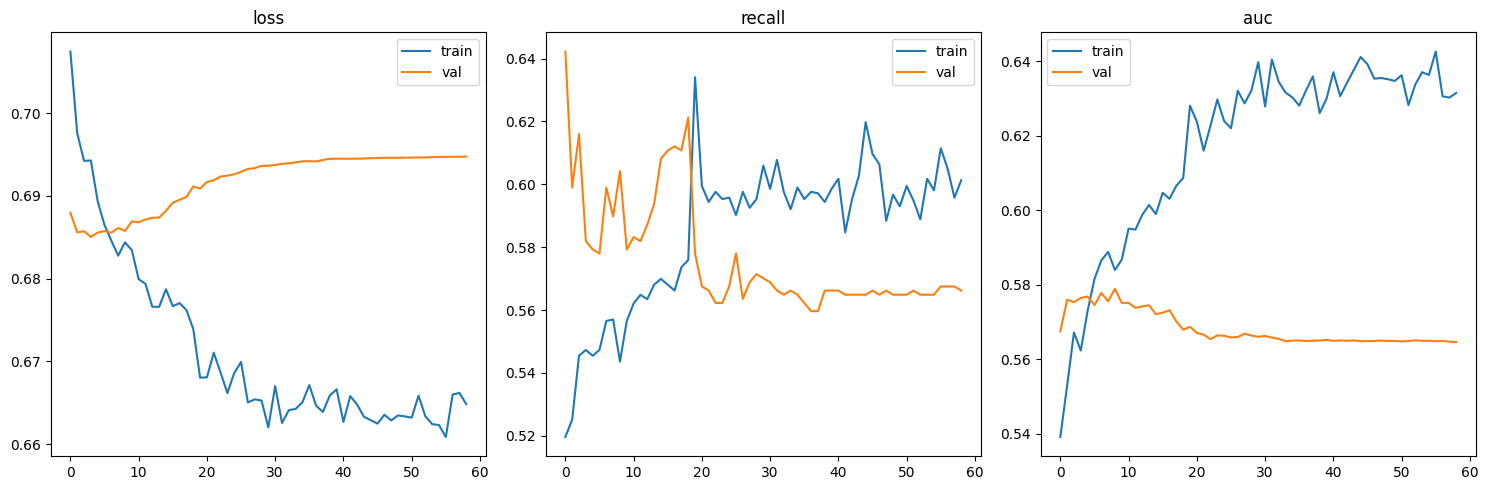

In [ ]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
]

# units / dropouts / lr come from tuning runs on train data only
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(203),
    Dropout(0.3460),
    Dense(89, activation='selu'),
    Dropout(0.0746),
    Dense(1, activation='sigmoid'),
])
model.compile(optimizer=Adam(learning_rate=0.0001476),
              loss='binary_crossentropy', metrics=metrics)

es = EarlyStopping(monitor='val_auc', mode='max', patience=50, restore_best_weights=True)
ck = ModelCheckpoint('best_gru.keras', monitor='val_auc', mode='max', save_best_only=True)
lr = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(X_val, y_val), class_weight=class_weights_dict,
                    callbacks=[es, ck, lr], verbose=1)

best_epoch = int(np.argmax(history.history['val_auc']))
print(f"Best val AUC: {history.history['val_auc'][best_epoch]:.4f} (epoch {best_epoch + 1})")

plt.figure(figsize=(15, 5))
for i, m in enumerate(['loss', 'recall', 'auc'], 1):
    plt.subplot(1, 3, i)
    plt.plot(history.history[m], label='train')
    plt.plot(history.history['val_' + m], label='val')
    plt.title(m)
    plt.legend()
plt.tight_layout()
plt.show()

## Calibrating Probabilities

n_val = 1502  ->  selected calibrator: ISOTONIC

              Brier   LogLoss
       raw   0.2453    0.6841
  isotonic   0.2419    0.6756
     platt   0.2447    0.6826

(in-sample on VAL, so isotonic always looks best here; the n_val rule above picks the calibrator, not this table)


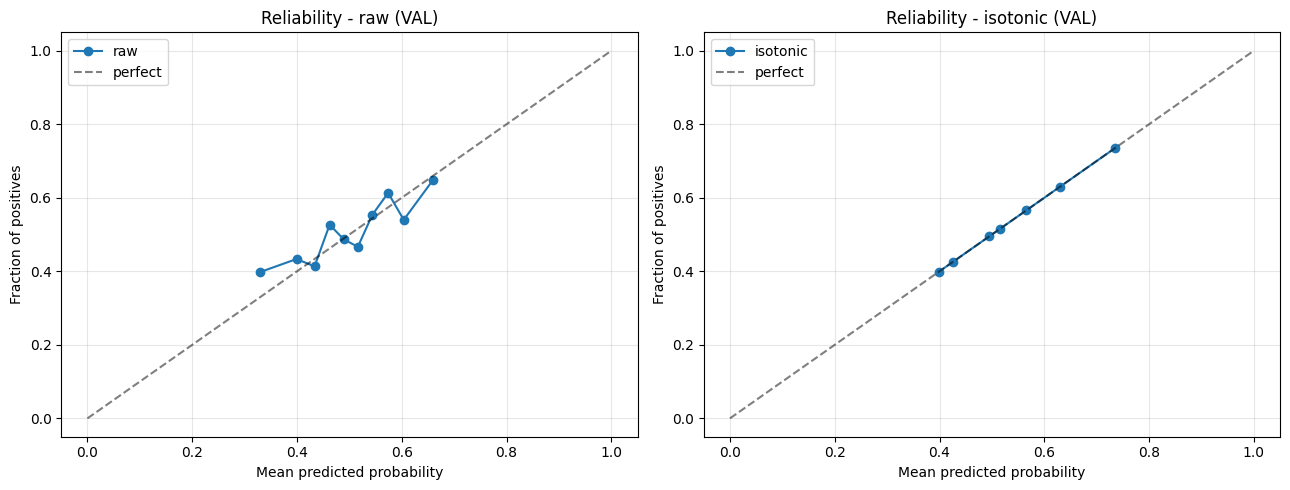

In [ ]:
_EPS = 1e-6

val_raw = model.predict(X_val, verbose=0).flatten()
iso_cal = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip').fit(val_raw, y_val)

def calibrate_probs(p_raw):
    p_raw = np.asarray(p_raw, dtype=np.float64).ravel()
    return np.clip(iso_cal.predict(p_raw), _EPS, 1 - _EPS)

val_iso = calibrate_probs(val_raw)

print(f"n_val = {len(y_val)}  ->  isotonic calibration\n")
print(f"{'':>10} {'Brier':>8} {'LogLoss':>9}")
for name, p in [('raw', np.clip(val_raw, _EPS, 1 - _EPS)), ('isotonic', val_iso)]:
    print(f"{name:>10} {brier_score_loss(y_val, p):>8.4f} {log_loss(y_val, p):>9.4f}")
print("\n(in-sample on VAL, so isotonic will always look better here)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (name, p) in zip(ax, [('raw', val_raw), ('isotonic', val_iso)]):
    frac_pos, mean_pred = calibration_curve(y_val, p, n_bins=10, strategy='quantile')
    a.plot(mean_pred, frac_pos, 'o-', label=name)
    a.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    a.set_xlabel('Mean predicted probability')
    a.set_ylabel('Fraction of positives')
    a.set_title(f'Reliability - {name} (VAL)')
    a.legend()
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

Val: 1502 signals over 155 days (avg 9.7 signals/day before filtering)


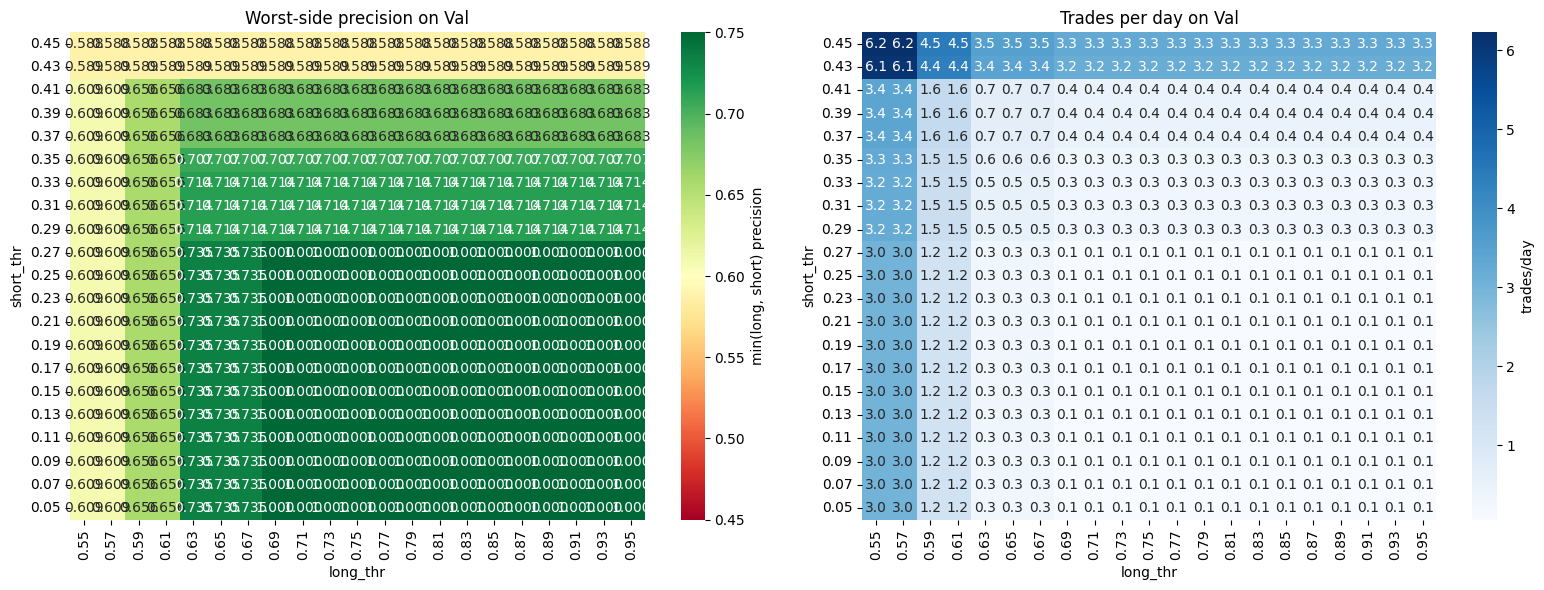

In [ ]:
# threshold tuning: grid search on calibrated VAL probabilities only

LOW_GRID  = np.arange(0.05, 0.46, 0.02)
HIGH_GRID = np.arange(0.55, 0.96, 0.02)

val_prob = calibrate_probs(model.predict(X_val, verbose=0).flatten())
val_dates = pd.Series(ts_m2_val).dt.normalize()
n_days = val_dates.nunique()
print(f"Val: {len(y_val)} signals over {n_days} days "
      f"(avg {len(y_val)/n_days:.1f} signals/day before filtering)")

rows = []
for t_lo in LOW_GRID:
    for t_hi in HIGH_GRID:
        long_m = val_prob >= t_hi
        short_m = val_prob <= t_lo
        trade_m = long_m | short_m
        n_long, n_short, n_trade = int(long_m.sum()), int(short_m.sum()), int(trade_m.sum())
        if n_trade == 0:
            continue
        long_p = ((y_val == 1) & long_m).sum() / n_long if n_long else 0.0
        short_p = ((y_val == 0) & short_m).sum() / n_short if n_short else 0.0
        if n_long == 0:
            min_p = short_p
        elif n_short == 0:
            min_p = long_p
        else:
            min_p = min(long_p, short_p)
        rows.append({
            'short_thr': round(t_lo, 3),
            'long_thr': round(t_hi, 3),
            'trades/day': n_trade / n_days,
            'n_longs': n_long,
            'n_shorts': n_short,
            'long_prec': long_p,
            'short_prec': short_p,
            'min_prec': min_p,
            'coverage_%': 100 * n_trade / len(y_val),
        })

grid = pd.DataFrame(rows)

piv_prec = grid.pivot(index='short_thr', columns='long_thr', values='min_prec')
piv_trades = grid.pivot(index='short_thr', columns='long_thr', values='trades/day')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(piv_prec, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.45, vmax=0.75,
            ax=ax[0], cbar_kws={'label': 'min(long, short) precision'})
ax[0].set_title('Worst-side precision on Val')
ax[0].invert_yaxis()
sns.heatmap(piv_trades, annot=True, fmt='.1f', cmap='Blues',
            ax=ax[1], cbar_kws={'label': 'trades/day'})
ax[1].set_title('Trades per day on Val')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()


========== Validation ==========
Window:  2024-03-25 -> 2026-04-09   (155 days)
Signals: 1502 total   (9.7/day)
Trades:  84   (0.54/day)   [5.6% coverage]
  Longs  (p >= 0.67):  49  (0.32/day)
  Shorts (p <= 0.29):  35  (0.23/day)

Daily trades  mean=0.54  median=0  std=0.79  min=0  max=4  0-trade days: 93 (60.0%)


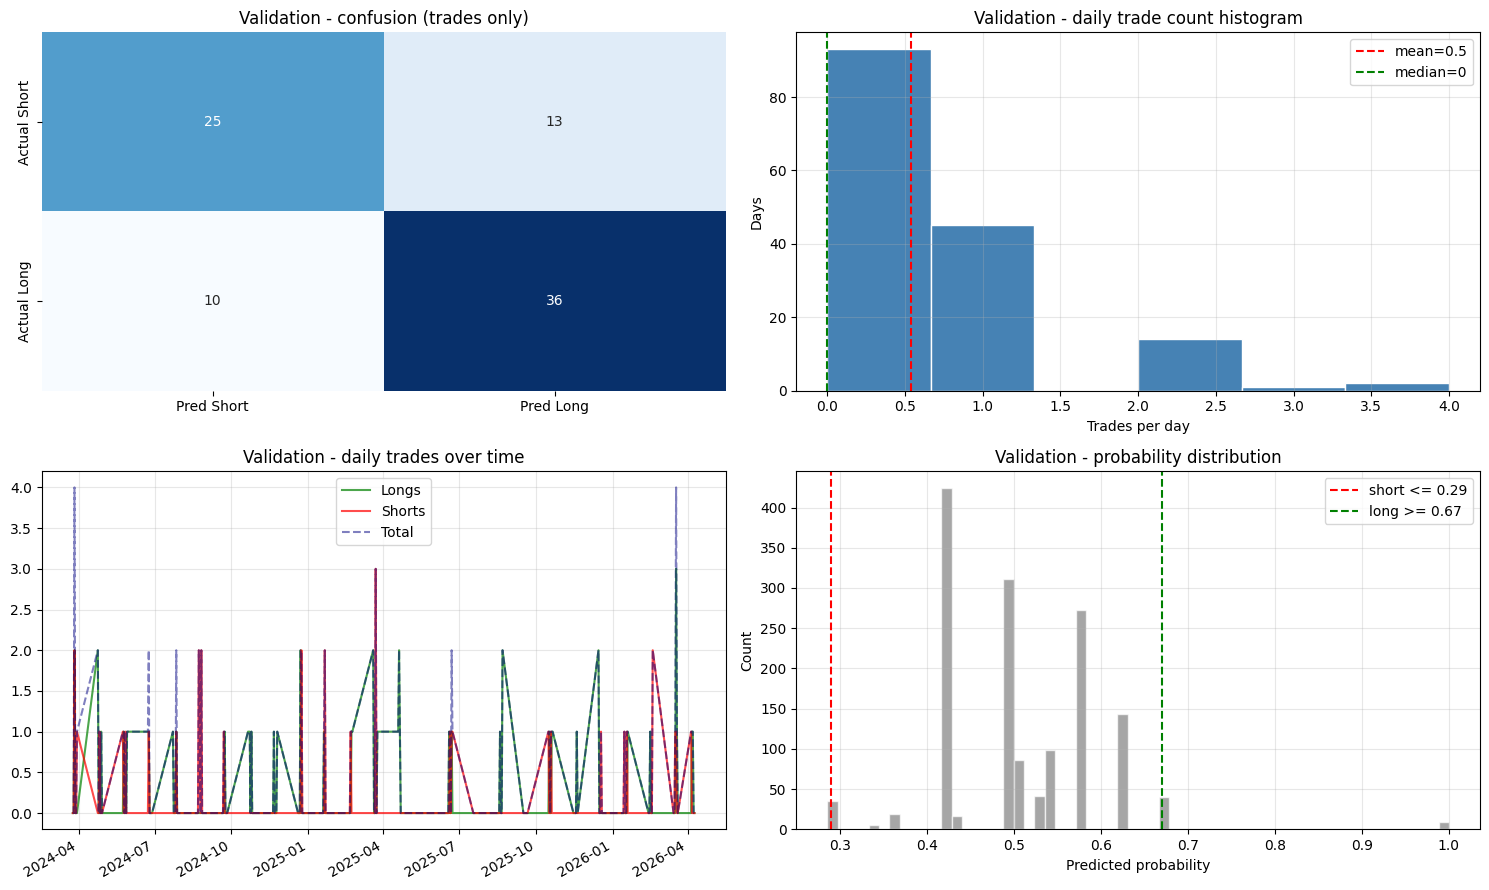


Classification report (trades only):
              precision    recall  f1-score   support

   Short (0)       0.71      0.66      0.68        38
    Long (1)       0.73      0.78      0.76        46

    accuracy                           0.73        84
   macro avg       0.72      0.72      0.72        84
weighted avg       0.73      0.73      0.72        84


========== Test ==========
Window:  2026-04-09 -> 2026-07-07   (90 days)
Signals: 989 total   (11.0/day)
Trades:  54   (0.60/day)   [5.5% coverage]
  Longs  (p >= 0.67):  40  (0.44/day)
  Shorts (p <= 0.29):  14  (0.16/day)

Daily trades  mean=0.60  median=0  std=0.67  min=0  max=2  0-trade days: 45 (50.0%)


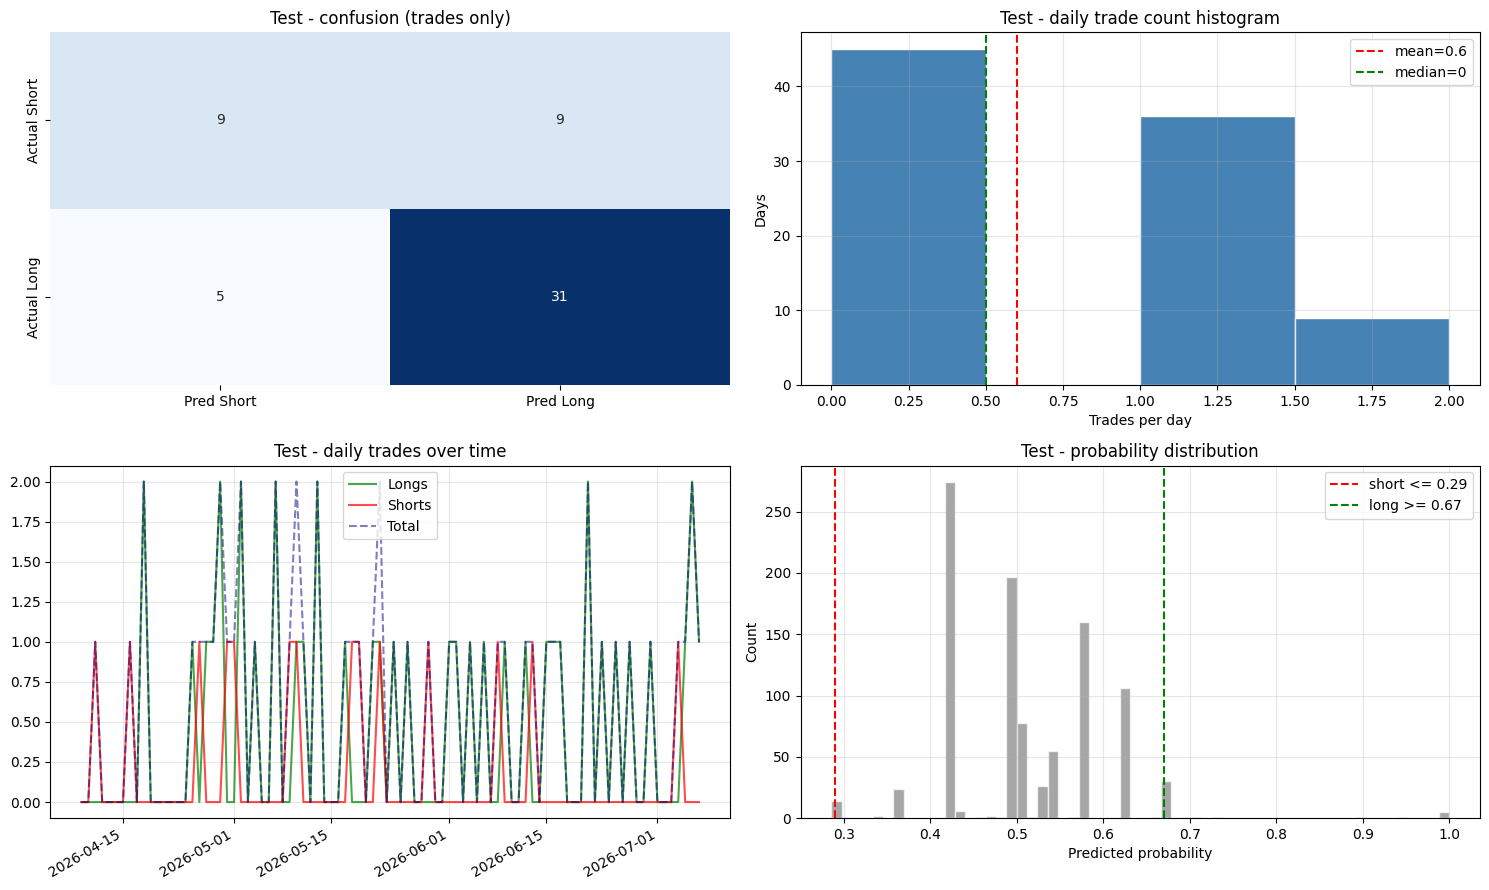


Classification report (trades only):
              precision    recall  f1-score   support

   Short (0)       0.64      0.50      0.56        18
    Long (1)       0.78      0.86      0.82        36

    accuracy                           0.74        54
   macro avg       0.71      0.68      0.69        54
weighted avg       0.73      0.74      0.73        54



In [ ]:
# chosen from the grid above (calibrated space)
LONG_THRESHOLD  = 0.67
SHORT_THRESHOLD = 0.29

def evaluate(X, y, times, name, mdl, long_thr, short_thr):
    prob = calibrate_probs(mdl.predict(X, verbose=0).flatten())
    long_m = prob >= long_thr
    short_m = prob <= short_thr
    trade_m = long_m | short_m
    n, n_tr, n_l, n_s = len(y), int(trade_m.sum()), int(long_m.sum()), int(short_m.sum())

    dates = pd.Series(times).dt.normalize()
    n_days = dates.nunique()

    print(f"\n========== {name} ==========")
    print(f"Window:  {dates.min().date()} -> {dates.max().date()}   ({n_days} days)")
    print(f"Signals: {n} total   ({n/n_days:.1f}/day)")
    print(f"Trades:  {n_tr}   ({n_tr/n_days:.2f}/day)   [{100*n_tr/n:.1f}% coverage]")
    print(f"  Longs  (p >= {long_thr}):  {n_l}  ({n_l/n_days:.2f}/day)")
    print(f"  Shorts (p <= {short_thr}):  {n_s}  ({n_s/n_days:.2f}/day)")
    if n_tr == 0:
        print("No trades.")
        return

    y_true = y[trade_m]
    y_pred = (prob[trade_m] >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    daily = (pd.DataFrame({'date': dates.values,
                           'trade': trade_m, 'long': long_m, 'short': short_m})
               .groupby('date')[['trade', 'long', 'short']].sum())
    print(f"\nDaily trades  mean={daily['trade'].mean():.2f}  "
          f"median={daily['trade'].median():.0f}  std={daily['trade'].std():.2f}  "
          f"min={int(daily['trade'].min())}  max={int(daily['trade'].max())}  "
          f"0-trade days: {(daily['trade']==0).sum()} ({100*(daily['trade']==0).mean():.1f}%)")

    fig, ax = plt.subplots(2, 2, figsize=(15, 9))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0, 0],
                xticklabels=['Pred Short', 'Pred Long'],
                yticklabels=['Actual Short', 'Actual Long'])
    ax[0, 0].set_title(f'{name} - confusion (trades only)')

    bins = min(30, int(daily['trade'].max()) + 2)
    ax[0, 1].hist(daily['trade'], bins=bins, color='steelblue', edgecolor='white')
    ax[0, 1].axvline(daily['trade'].mean(), color='red', linestyle='--',
                     label=f"mean={daily['trade'].mean():.1f}")
    ax[0, 1].axvline(daily['trade'].median(), color='green', linestyle='--',
                     label=f"median={daily['trade'].median():.0f}")
    ax[0, 1].set_xlabel('Trades per day')
    ax[0, 1].set_ylabel('Days')
    ax[0, 1].set_title(f'{name} - daily trade count histogram')
    ax[0, 1].legend()
    ax[0, 1].grid(alpha=0.3)

    ax[1, 0].plot(daily.index, daily['long'], color='green', alpha=0.7, label='Longs')
    ax[1, 0].plot(daily.index, daily['short'], color='red', alpha=0.7, label='Shorts')
    ax[1, 0].plot(daily.index, daily['trade'], color='navy', linestyle='--', alpha=0.5, label='Total')
    ax[1, 0].set_title(f'{name} - daily trades over time')
    ax[1, 0].legend()
    ax[1, 0].grid(alpha=0.3)
    plt.setp(ax[1, 0].xaxis.get_majorticklabels(), rotation=30, ha='right')

    ax[1, 1].hist(prob, bins=60, color='gray', edgecolor='white', alpha=0.7)
    ax[1, 1].axvline(short_thr, color='red', linestyle='--', label=f'short <= {short_thr}')
    ax[1, 1].axvline(long_thr, color='green', linestyle='--', label=f'long >= {long_thr}')
    ax[1, 1].set_xlabel('Predicted probability')
    ax[1, 1].set_ylabel('Count')
    ax[1, 1].set_title(f'{name} - probability distribution')
    ax[1, 1].legend()
    ax[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nClassification report (trades only):")
    print(classification_report(y_true, y_pred, labels=[0, 1], zero_division=0,
                                target_names=['Short (0)', 'Long (1)']))

evaluate(X_val, y_val, ts_m2_val, "Validation", model, LONG_THRESHOLD, SHORT_THRESHOLD)
evaluate(X_test, y_test, ts_m2_test, "Test", model, LONG_THRESHOLD, SHORT_THRESHOLD)

In [ ]:
# expected TRADABLE precision on TEST = accuracy x label agreement
ts_test = pd.DatetimeIndex(ts_m2_test)
prob = calibrate_probs(model.predict(X_test, verbose=0).flatten())

long_m = prob >= LONG_THRESHOLD
short_m = prob <= SHORT_THRESHOLD
trade_m = long_m | short_m

print(f"TEST window:  {ts_test.min().date()} -> {ts_test.max().date()}  "
      f"({ts_test.normalize().nunique()} days, {len(y_test)} signals)")
print(f"Thresholds:   long >= {LONG_THRESHOLD}   short <= {SHORT_THRESHOLD}")
print(f"Trades:       {int(trade_m.sum())}  "
      f"({int(long_m.sum())}L / {int(short_m.sum())}S)")

if trade_m.sum() == 0:
    print("No trades at these thresholds.")
else:
    # accuracy on traded signals, vs the smoothed ground truth
    pred = long_m.astype(int)
    n_trades = int(trade_m.sum())
    n_correct = int((pred[trade_m] == y_test[trade_m]).sum())
    acc = n_correct / n_trades

    # raw/smoothed label agreement on those same timestamps
    traded_ts = ts_test[trade_m]
    lbls = final_training_data.loc[
        final_training_data.index.intersection(traded_ts),
        ['target_smoothed', 'target_raw']]
    lbls = lbls[(lbls['target_smoothed'] != -1) & (lbls['target_raw'] != -1)]
    n_agree = int((lbls['target_smoothed'] == lbls['target_raw']).sum())
    agree = n_agree / len(lbls)

    exp_simple = acc * agree
    exp_full = acc * agree + (1 - acc) * (1 - agree)   # wrong call + flip = raw win

    print(f"\nCorrectly labeled trades: {n_correct}/{n_trades}  ({100*acc:.1f}%)")
    print(f"Agreeing labels:          {n_agree}/{len(lbls)}  ({100*agree:.1f}%)")
    print(f"\nExpected tradable precision:")
    print(f"  simple (acc x agree):        {100*exp_simple:.1f}%")
    print(f"  full   (incl. lucky flips):  {100*exp_full:.1f}%")

TEST window:  2026-04-09 -> 2026-07-07  (90 days, 989 signals)
Thresholds:   long >= 0.67   short <= 0.29
Trades:       54  (40L / 14S)

Correctly labeled trades: 40/54  (74.1%)
Agreeing labels:          44/54  (81.5%)

Expected tradable precision:
  simple (acc x agree):        60.4%
  full   (incl. lucky flips):  65.2%
